# Experiment: CV HW1 Collaborative Scaffold

Objective:
- Complete homework Step 1-4 and the MLP part of Step 5 in a reusable way.
- Leave shared training and evaluation hooks so teammates can continue with CNN, ResNet, and ViT.


## Collaboration Notes

- Keep shared logic in `hw1_framework.py` so notebook cells stay short and easy to merge.
- Use the `RUN_*` flags before launching long experiments.
- Teammates should reuse the shared data split and training wrapper instead of writing separate loops.


In [ ]:
# Core notebook imports.
from pathlib import Path
import copy

import matplotlib.pyplot as plt

import pandas as pd

import hw1_framework as hw


/home/ykshi/miniconda3/envs/colpali/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Resolve the project root and create shared output folders.
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "CV_HW1":
    PROJECT_DIR = Path("/home/ykshi/cv/CV_Group8_HW1")

project_paths = hw.ensure_project_dirs(PROJECT_DIR)
runtime_config = hw.get_default_runtime_config(PROJECT_DIR)

# Fix the seed once so everyone uses the same dataset split and training randomness.
hw.set_seed(runtime_config["seed"])
device = hw.get_device()

print(f"Project directory: {PROJECT_DIR}")
print(f"Device: {device}")
print(f"Output folders: {project_paths}")


Project directory: /home/ykshi/cv/CV_Group8_HW1
Device: cuda
Output folders: {'root': PosixPath('/home/ykshi/cv/CV_Group8_HW1'), 'data': PosixPath('/home/ykshi/cv/CV_Group8_HW1/data'), 'figures': PosixPath('/home/ykshi/cv/CV_Group8_HW1/figures'), 'models': PosixPath('/home/ykshi/cv/CV_Group8_HW1/models'), 'results': PosixPath('/home/ykshi/cv/CV_Group8_HW1/results')}


## Step 1-4: Data Loading, Split, And Visualization

This section covers the reusable part of the homework that all four models share.


In [3]:
# Load EMNIST Balanced with one fixed train/validation/test setup.
loaders = hw.load_emnist_balanced(
    data_dir=runtime_config["data_dir"],
    batch_size=runtime_config["batch_size"],
    valid_ratio=runtime_config["valid_ratio"],
    num_workers=runtime_config["num_workers"],
    subset_ratio=1.0,
    augment=runtime_config["augment"],
    rotation_deg=runtime_config["rotation_deg"],
    noise_std=runtime_config["noise_std"],
    blur=runtime_config["blur"],
    seed=runtime_config["seed"],
)

class_names = loaders["class_names"]
dataset_stats = hw.show_dataset_stats(
    loaders["train_dataset"],
    loaders["valid_dataset"],
    loaders["test_dataset"],
    class_names,
)
dataset_stats


  split  samples
  train   101520
  valid    11280
   test    18800
classes       47


,split,samples
0,train,101520
1,valid,11280
2,test,18800
3,classes,47


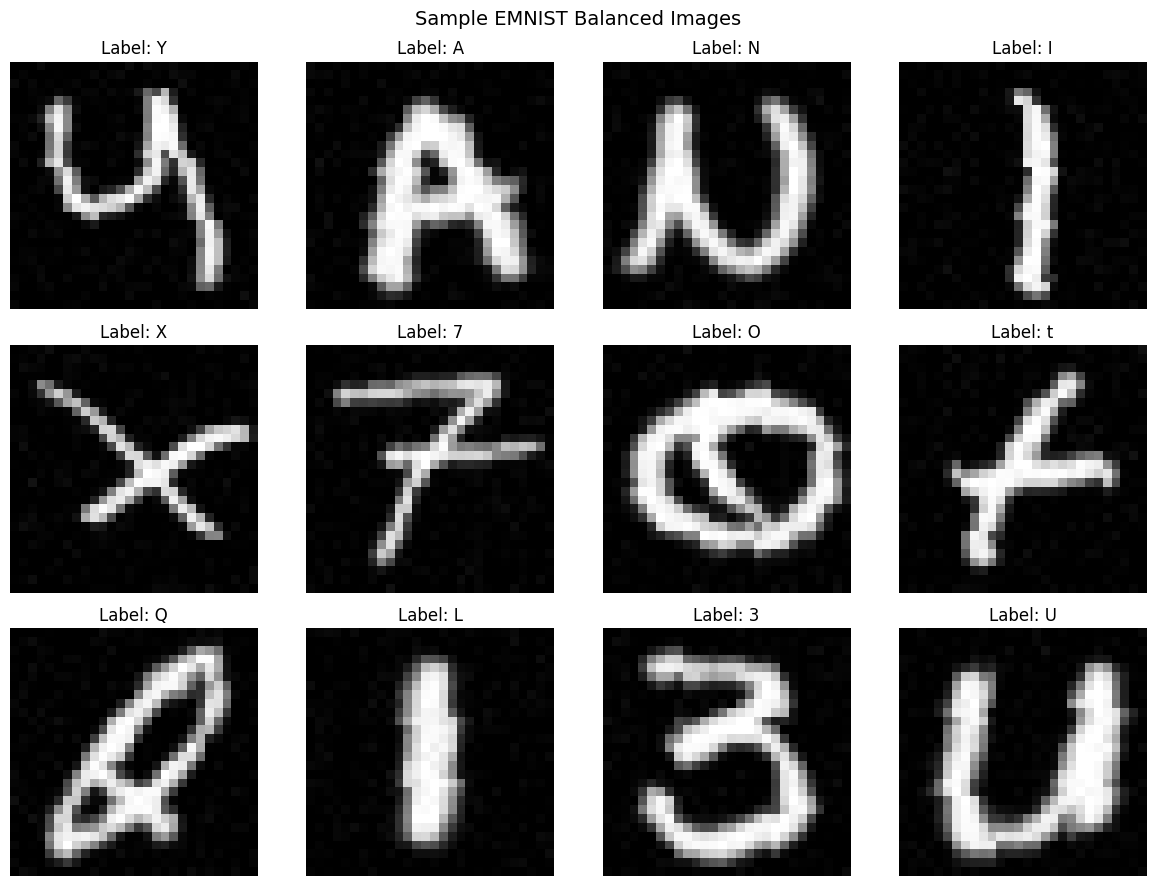

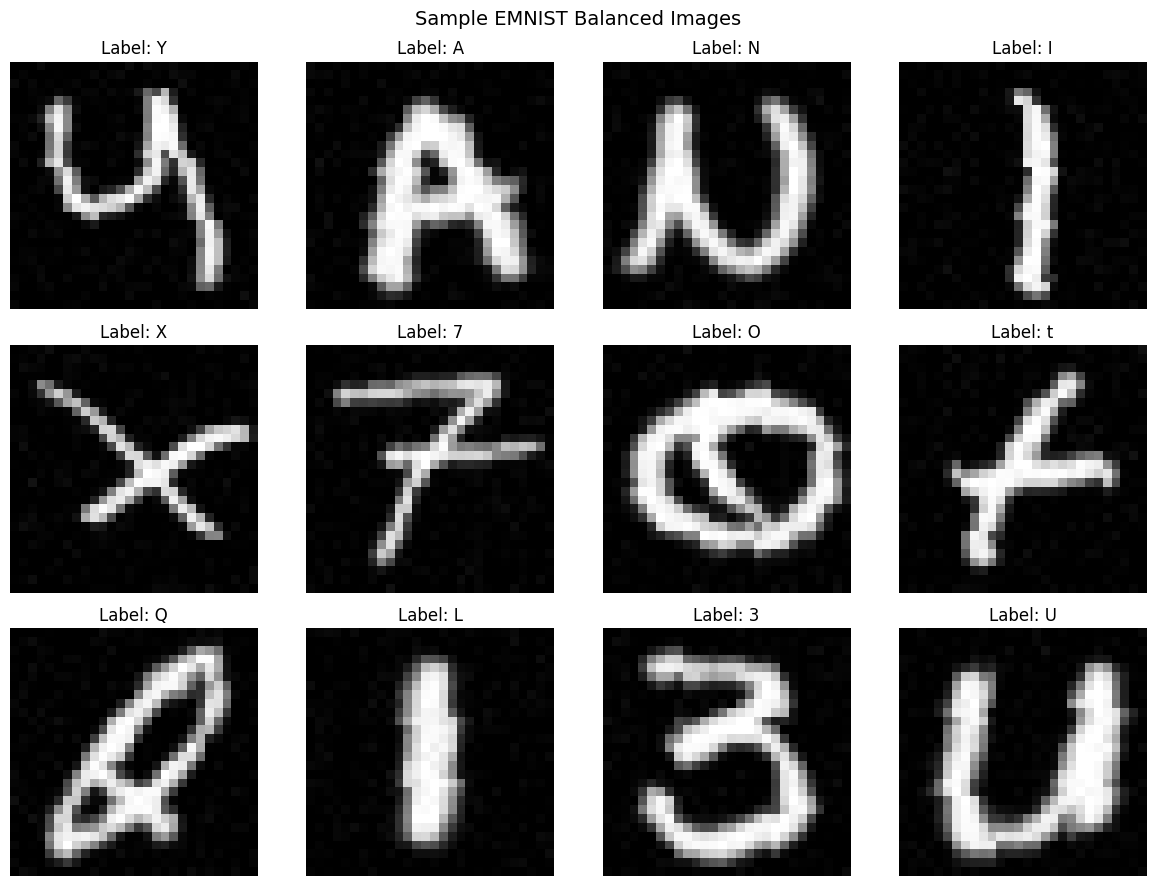

In [4]:
# Plot a few samples so the team can verify label coverage and image orientation early.
sample_figure = hw.show_sample_images(
    dataset=loaders["train_dataset"],
    class_names=class_names,
    num_samples=12,
    seed=runtime_config["seed"],
)
sample_figure


## MLP Baseline And Search Plan

The workflow below is the template that the other three model owners can reuse later.


In [ ]:
# Start from one stable baseline, then replace one factor at a time.
mlp_config = hw.get_default_mlp_config()
mlp_search_plan = {
    "scheduler": ["StepLR", "CosineAnnealingLR", "ReduceLROnPlateau"],
    "activation": ["relu", "leaky_relu", "gelu"],
    "optimizer": ["adam", "sgd", "rmsprop"],
    "normalization": ["batchnorm", "layernorm", "none"],
    "dropout": [0.0, 0.3, 0.5],
}

# L1 and L2 change two fields together, so they are tracked separately from the single-factor loop.
mlp_regularization_trials = [
    {"name": "no_regularization", "l1_lambda": 0.0, "weight_decay": 0.0},
    {"name": "l1_regularization", "l1_lambda": 1e-6, "weight_decay": 0.0},
    {"name": "l2_regularization", "l1_lambda": 0.0, "weight_decay": 1e-4},
]

pd.Series(mlp_config, name="baseline_value")


In [ ]:
# Preview the MLP structure before training and record its parameter count for the report.
mlp_preview = hw.build_mlp(mlp_config)
print(mlp_preview)
print(f"Trainable parameters: {hw.count_parameters(mlp_preview):,}")


In [ ]:
# Keep heavy retraining opt-in. The saved baseline result is shown in the snapshot section below.
RUN_MLP_BASELINE = False

if RUN_MLP_BASELINE:
    mlp_baseline_result = hw.run_training_experiment(
        model_name="mlp_baseline",
        model_builder=hw.build_mlp,
        config=mlp_config,
        loaders=loaders,
        device=device,
        output_dir=project_paths["models"],
    )
    mlp_baseline_curves = hw.plot_training_curves(
        mlp_baseline_result["history"],
        "MLP Baseline",
    )
    mlp_baseline_summary = pd.DataFrame([mlp_baseline_result["summary"]])
    mlp_baseline_summary
else:
    print("已跳过重新训练 MLP baseline；下方结果快照会直接展示已保存结果。")


In [ ]:
# Sequential search remains opt-in because it is time-consuming.
RUN_MLP_SEARCH = False

if RUN_MLP_SEARCH:
    search_tables = []
    tuned_mlp_config = copy.deepcopy(mlp_config)

    for factor_name, candidate_values in mlp_search_plan.items():
        factor_result = hw.run_single_factor_search(
            model_name="mlp",
            model_builder=hw.build_mlp,
            base_config=tuned_mlp_config,
            factor_name=factor_name,
            candidate_values=candidate_values,
            loaders=loaders,
            device=device,
            output_dir=project_paths["models"] / "search",
        )
        search_tables.append(factor_result["results"])
        tuned_mlp_config = factor_result["best_config"]

    regularization_rows = []
    best_regularized_config = copy.deepcopy(tuned_mlp_config)
    best_regularization_score = float("-inf")
    for trial in mlp_regularization_trials:
        trial_config = copy.deepcopy(tuned_mlp_config)
        trial_config["l1_lambda"] = trial["l1_lambda"]
        trial_config["weight_decay"] = trial["weight_decay"]
        trial_result = hw.run_training_experiment(
            model_name=f"mlp_{trial['name']}",
            model_builder=hw.build_mlp,
            config=trial_config,
            loaders=loaders,
            device=device,
            output_dir=project_paths["models"] / "search",
        )
        regularization_rows.append(
            {
                "factor": "regularization",
                "candidate": trial["name"],
                "best_valid_accuracy": trial_result["summary"]["best_valid_accuracy"],
                "best_epoch": trial_result["summary"]["best_epoch"],
                "training_time_sec": trial_result["summary"]["training_time_sec"],
            }
        )
        if trial_result["summary"]["best_valid_accuracy"] > best_regularization_score:
            best_regularization_score = trial_result["summary"]["best_valid_accuracy"]
            best_regularized_config = trial_config

    tuned_mlp_config = best_regularized_config
    mlp_search_results = pd.concat(
        [*search_tables, pd.DataFrame(regularization_rows)],
        ignore_index=True,
    )
    mlp_search_results
else:
    tuned_mlp_config = copy.deepcopy(mlp_config)
    print("已跳过重新运行 MLP 调参搜索；下方结果快照会展示已保存搜索结果。")


In [ ]:
# Final training stays optional because the saved final checkpoint and metrics already exist.
RUN_MLP_FINAL = False

if RUN_MLP_FINAL:
    mlp_final_result = hw.run_training_experiment(
        model_name="mlp_best",
        model_builder=hw.build_mlp,
        config=tuned_mlp_config,
        loaders=loaders,
        device=device,
        output_dir=project_paths["models"],
    )
    mlp_final_curves = hw.plot_training_curves(
        mlp_final_result["history"],
        "MLP Best Model",
    )
    mlp_test_metrics = hw.evaluate_on_test(
        mlp_final_result["model"],
        loaders["test_loader"],
        device,
    )
    mlp_metric_table = pd.DataFrame([hw.summarize_metrics(mlp_test_metrics)])
    mlp_metric_table
else:
    print("已跳过重新训练最终 MLP；下方结果快照会展示最终指标和曲线图。")


In [ ]:
# Re-render the visualizations only when you really need to regenerate them.
if "mlp_final_result" in globals():
    prediction_figure = hw.preview_predictions(
        model=mlp_final_result["model"],
        loader=loaders["test_loader"],
        class_names=class_names,
        device=device,
        num_samples=6,
    )
    confusion_figure = hw.plot_confusion_matrix_from_preds(
        y_true=mlp_test_metrics["y_true"],
        y_pred=mlp_test_metrics["y_pred"],
        class_names=class_names,
        model_name="MLP",
    )
    prediction_figure
    confusion_figure
else:
    print("已完成的预测样例和混淆矩阵会在下方结果快照中直接显示。")


In [ ]:
# The saved small-sample comparison is shown below by default.
RUN_MLP_SMALL_SAMPLE = False

if RUN_MLP_SMALL_SAMPLE:
    mlp_small_sample_df, mlp_small_sample_runs = hw.run_small_sample_experiment(
        model_name="mlp",
        model_builder=hw.build_mlp,
        base_config=tuned_mlp_config,
        runtime_config=runtime_config,
        sample_ratios=[0.3, 0.5, 1.0],
        device=device,
        output_dir=project_paths["models"],
    )
    mlp_small_sample_df
else:
    print("已跳过重新运行小样本实验；下方结果快照会展示已保存的小样本结果。")


## 已完成结果快照

以下内容直接读取 `results/`、`figures/` 和 `models/` 中已保存的结果。其他同学打开 notebook 后，无需重新训练即可查看你已完成部分的完整输出。

In [ ]:
# 直接加载并展示已保存结果，让组员打开 notebook 就能看到当前完成状态。
import json
from IPython.display import Image, Markdown, display

saved_summary_path = PROJECT_DIR / "results" / "mlp_experiment_summary.json"
saved_small_sample_path = PROJECT_DIR / "results" / "mlp_small_sample_results.csv"
saved_search_path = PROJECT_DIR / "results" / "mlp_search_results.csv"
saved_metric_path = PROJECT_DIR / "results" / "mlp_metric_summary.csv"

figure_paths = {
    "训练/验证曲线": PROJECT_DIR / "figures" / "mlp_final_curves.png",
    "前 6 个测试样本预测": PROJECT_DIR / "figures" / "mlp_final_predictions.png",
    "测试集混淆矩阵": PROJECT_DIR / "figures" / "mlp_final_confusion_matrix.png",
    "30% / 50% / 100% 小样本对比": PROJECT_DIR / "figures" / "mlp_small_sample.png",
}

if saved_summary_path.exists():
    with saved_summary_path.open("r", encoding="utf-8") as f:
        saved_summary = json.load(f)

    display(Markdown("### 1. 已完成步骤状态"))
    completion_df = pd.DataFrame([
        {"步骤": "Step 1-4 数据加载、划分、可视化", "状态": "已完成", "说明": "数据统计和样本图像见上方单元"},
        {"步骤": "MLP baseline", "状态": "已完成", "说明": "已完成训练并保存 checkpoint"},
        {"步骤": "MLP 调参搜索", "状态": "已完成", "说明": "已完成 scheduler/activation/optimizer/normalization/dropout/regularization 搜索"},
        {"步骤": "MLP 最终模型", "状态": "已完成", "说明": "已完成最终训练、测试评估与图像保存"},
        {"步骤": "MLP 小样本实验", "状态": "已完成", "说明": "已完成 30% / 50% / 100% 对比"},
    ])
    display(completion_df)

    display(Markdown("### 2. 数据集划分结果"))
    dataset_snapshot = pd.DataFrame([
        {"split": "train", "samples": len(loaders["train_dataset"]), "classes": len(class_names)},
        {"split": "valid", "samples": len(loaders["valid_dataset"]), "classes": len(class_names)},
        {"split": "test", "samples": len(loaders["test_dataset"]), "classes": len(class_names)},
    ])
    display(dataset_snapshot)

    display(Markdown("### 3. Baseline 与最终模型指标对比"))
    metric_table = pd.DataFrame([
        {"stage": "baseline_valid", **saved_summary["baseline_valid_metrics"]},
        {"stage": "baseline_test", **saved_summary["baseline_test_metrics"]},
        {"stage": "final_valid", **saved_summary["final_valid_metrics"]},
        {"stage": "final_test", **saved_summary["final_test_metrics"]},
    ])
    display(metric_table.round(4))

    improvement_table = pd.DataFrame([
        {
            "指标": "accuracy",
            "baseline_test": saved_summary["baseline_test_metrics"]["accuracy"],
            "final_test": saved_summary["final_test_metrics"]["accuracy"],
            "提升": saved_summary["final_test_metrics"]["accuracy"] - saved_summary["baseline_test_metrics"]["accuracy"],
        },
        {
            "指标": "f1_macro",
            "baseline_test": saved_summary["baseline_test_metrics"]["f1_macro"],
            "final_test": saved_summary["final_test_metrics"]["f1_macro"],
            "提升": saved_summary["final_test_metrics"]["f1_macro"] - saved_summary["baseline_test_metrics"]["f1_macro"],
        },
    ])
    display(improvement_table.round(4))

    display(Markdown("### 4. 最终 MLP 配置"))
    final_config_df = pd.json_normalize(saved_summary["final_config"])
    display(final_config_df)

    display(Markdown("### 5. 调参搜索结果"))
    search_df = pd.read_csv(saved_search_path)
    if "selected" not in search_df.columns:
        search_df["selected"] = False
        best_indices = search_df.groupby("search_name")["best_valid_accuracy"].idxmax()
        search_df.loc[best_indices, "selected"] = True
    display(search_df.sort_values(["search_name", "best_valid_accuracy"], ascending=[True, False]).round(4))

    display(Markdown("### 6. 小样本实验结果"))
    small_sample_df = pd.read_csv(saved_small_sample_path)
    display(small_sample_df.round(4))

    display(Markdown("### 7. 关键图形结果"))
    for title, image_path in figure_paths.items():
        if image_path.exists():
            display(Markdown(f"#### {title}"))
            display(Image(filename=str(image_path)))

    display(Markdown("### 8. 已保存的重要产物"))
    artifact_rows = []
    for name, file_path in {
        "最终配置": PROJECT_DIR / "results" / "mlp_best_config.json",
        "指标汇总": saved_metric_path,
        "搜索结果": saved_search_path,
        "小样本结果": saved_small_sample_path,
        "实验总结": saved_summary_path,
        "最终 checkpoint": PROJECT_DIR / "models" / "mlp_final_best.pt",
    }.items():
        artifact_rows.append({"产物": name, "路径": str(file_path), "存在": file_path.exists()})
    display(pd.DataFrame(artifact_rows))
else:
    print("未找到已保存结果文件，请先运行 run_mlp_pipeline.py。")


## Scaffolds For The Other Three Models

These configs and builders are ready for the teammates who own CNN, ResNet, and ViT.


In [5]:
# Every teammate should start here and then tune only their own model-specific config.
cnn_config = hw.get_default_cnn_config()
resnet_config = hw.get_default_resnet_config()
vit_config = hw.get_default_vit_config()

scaffold_rows = []
for model_name, config in {
    "cnn": cnn_config,
    "resnet": resnet_config,
    "vit": vit_config,
}.items():
    model = hw.MODEL_BUILDERS[model_name](config)
    scaffold_rows.append(
        {
            "model": model_name,
            "trainable_parameters": hw.count_parameters(model),
            "config_ready": True,
        }
    )

pd.DataFrame(scaffold_rows)


,model,trainable_parameters,config_ready
0,cnn,99183,True
1,resnet,312847,True
2,vit,544943,True


## CNN 已完成结果快照

以下内容直接读取 `results/`、`figures/` 和 `models/` 中已保存的 CNN 结果。打开 notebook 时无需重新训练，就能看到 CNN 的 baseline、调参、最终模型和小样本实验输出。


37.9%IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

100.0%


### 1. 已完成步骤状态

,步骤,状态,说明
0,CNN baseline,已完成,已完成默认配置训练并保存曲线
1,CNN 调参搜索,已完成,已完成 channels / scheduler / activation / optimi...
2,CNN 最终模型,已完成,已完成最终训练、测试评估与图像保存
3,CNN 小样本实验,已完成,已完成 30% / 50% / 100% 对比


### 2. Baseline 与最终模型指标对比

,stage,loss,accuracy,precision_macro,recall_macro,f1_macro
0,baseline_valid,0.3536,0.8749,0.8817,0.8767,0.8742
1,baseline_test,0.3586,0.8754,0.8806,0.8754,0.8734
2,final_valid,0.3033,0.8926,0.8985,0.8945,0.8930
3,final_test,0.3098,0.8931,0.8965,0.8931,0.8920


...

,search_name,candidate,best_valid_accuracy,best_valid_loss,best_epoch,training_time_sec,selected
6,activation,relu,0.8484,0.4564,8,142.4398,True
7,activation,leaky_relu,0.8464,0.4566,8,144.2810,False
8,activation,elu,0.8406,0.4873,8,152.5404,False
2,channels,c32_64_128,0.8457,0.4757,8,142.1581,True
1,channels,c64_128,0.5243,1.9448,8,235.0061,False
0,channels,c32_64,0.3847,2.4326,8,128.8597,False
16,dropout,dropout_0.0,0.8596,0.4014,7,139.4550,True
17,dropout,dropout_0.3,0.8434,0.4577,8,139.7698,False
18,dropout,dropout_0.5,0.8009,0.6767,8,139.7458,False
13,normalization,batchnorm,0.8592,0.4121,8,140.8288,True


### 5. 小样本实验结果

,sample_ratio,train_samples,best_valid_accuracy,test_accuracy,test_f1_macro
0,0.3,30456,0.8824,0.8807,0.8787
1,0.5,50760,0.8887,0.8878,0.8867
2,1.0,101520,0.8924,0.8912,0.8899


### 6. 关键图形结果

#### 训练/验证曲线

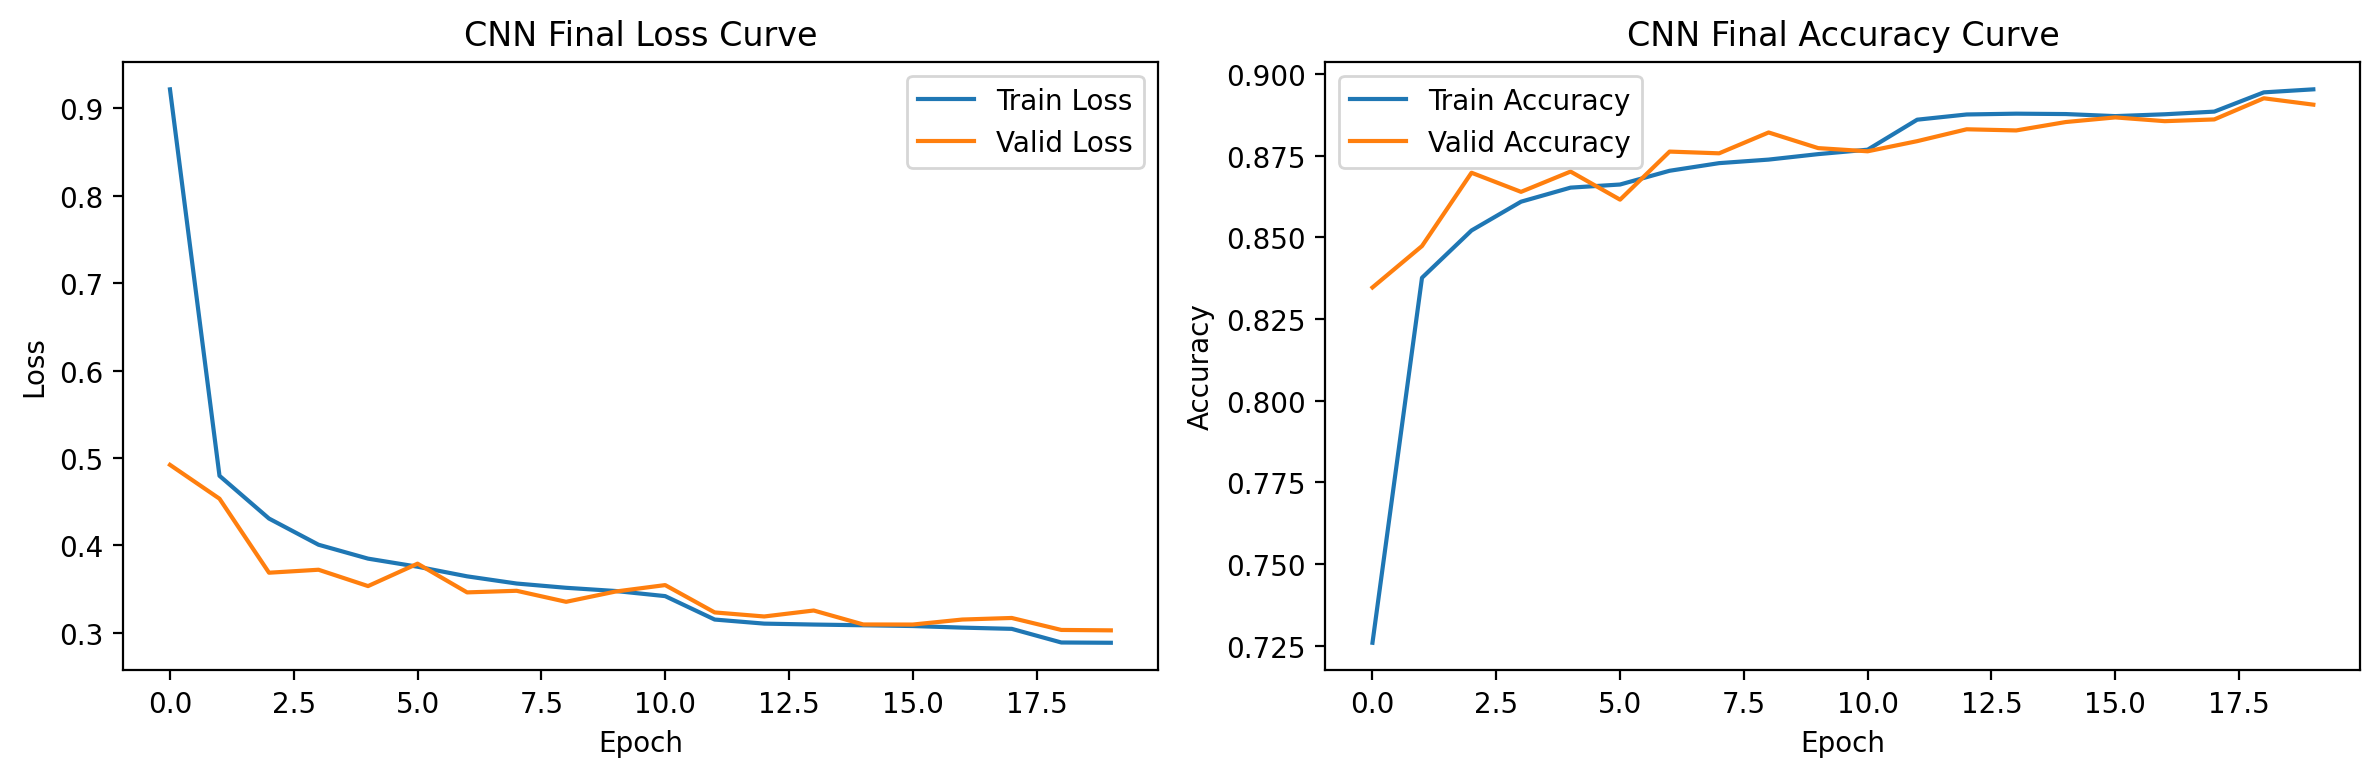

#### 前 6 个测试样本预测

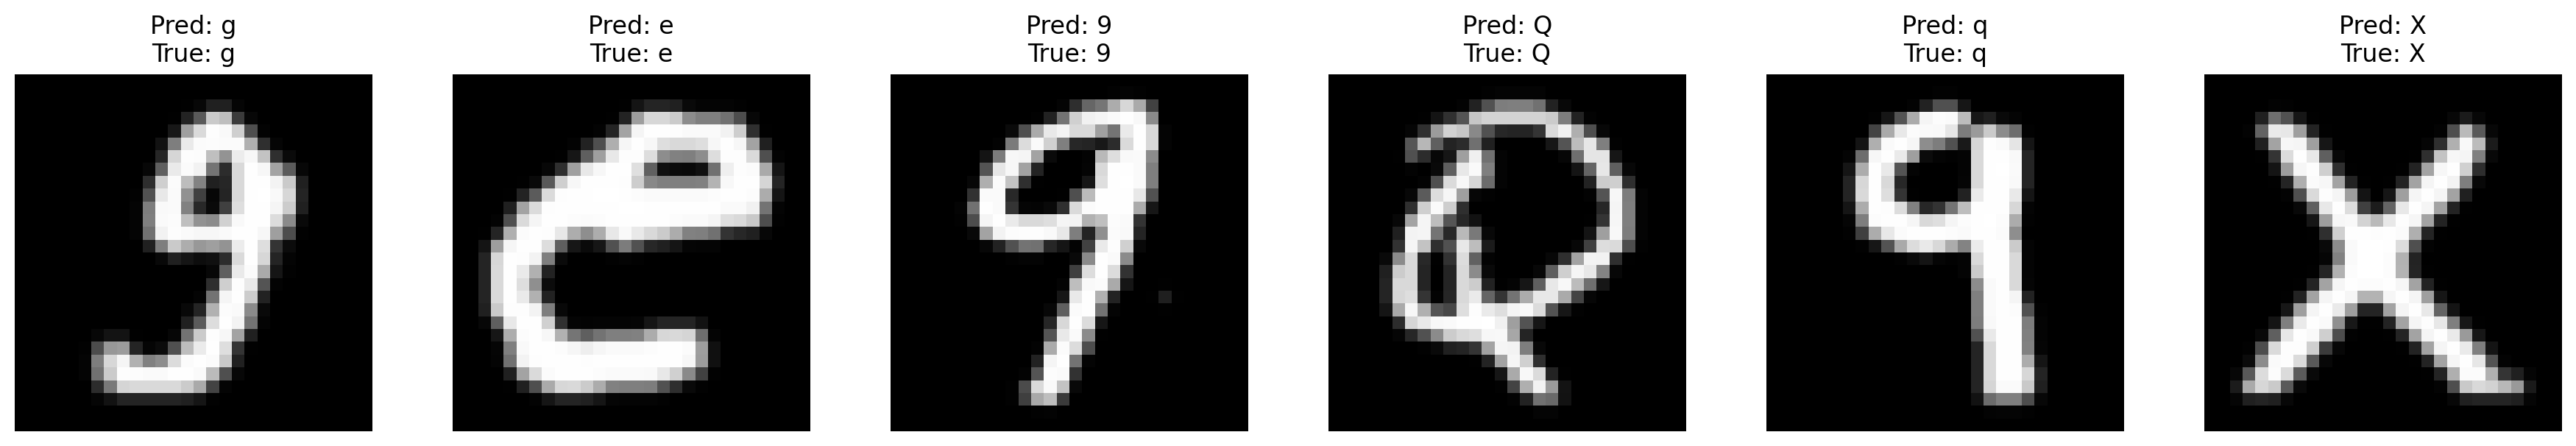

#### 测试集混淆矩阵

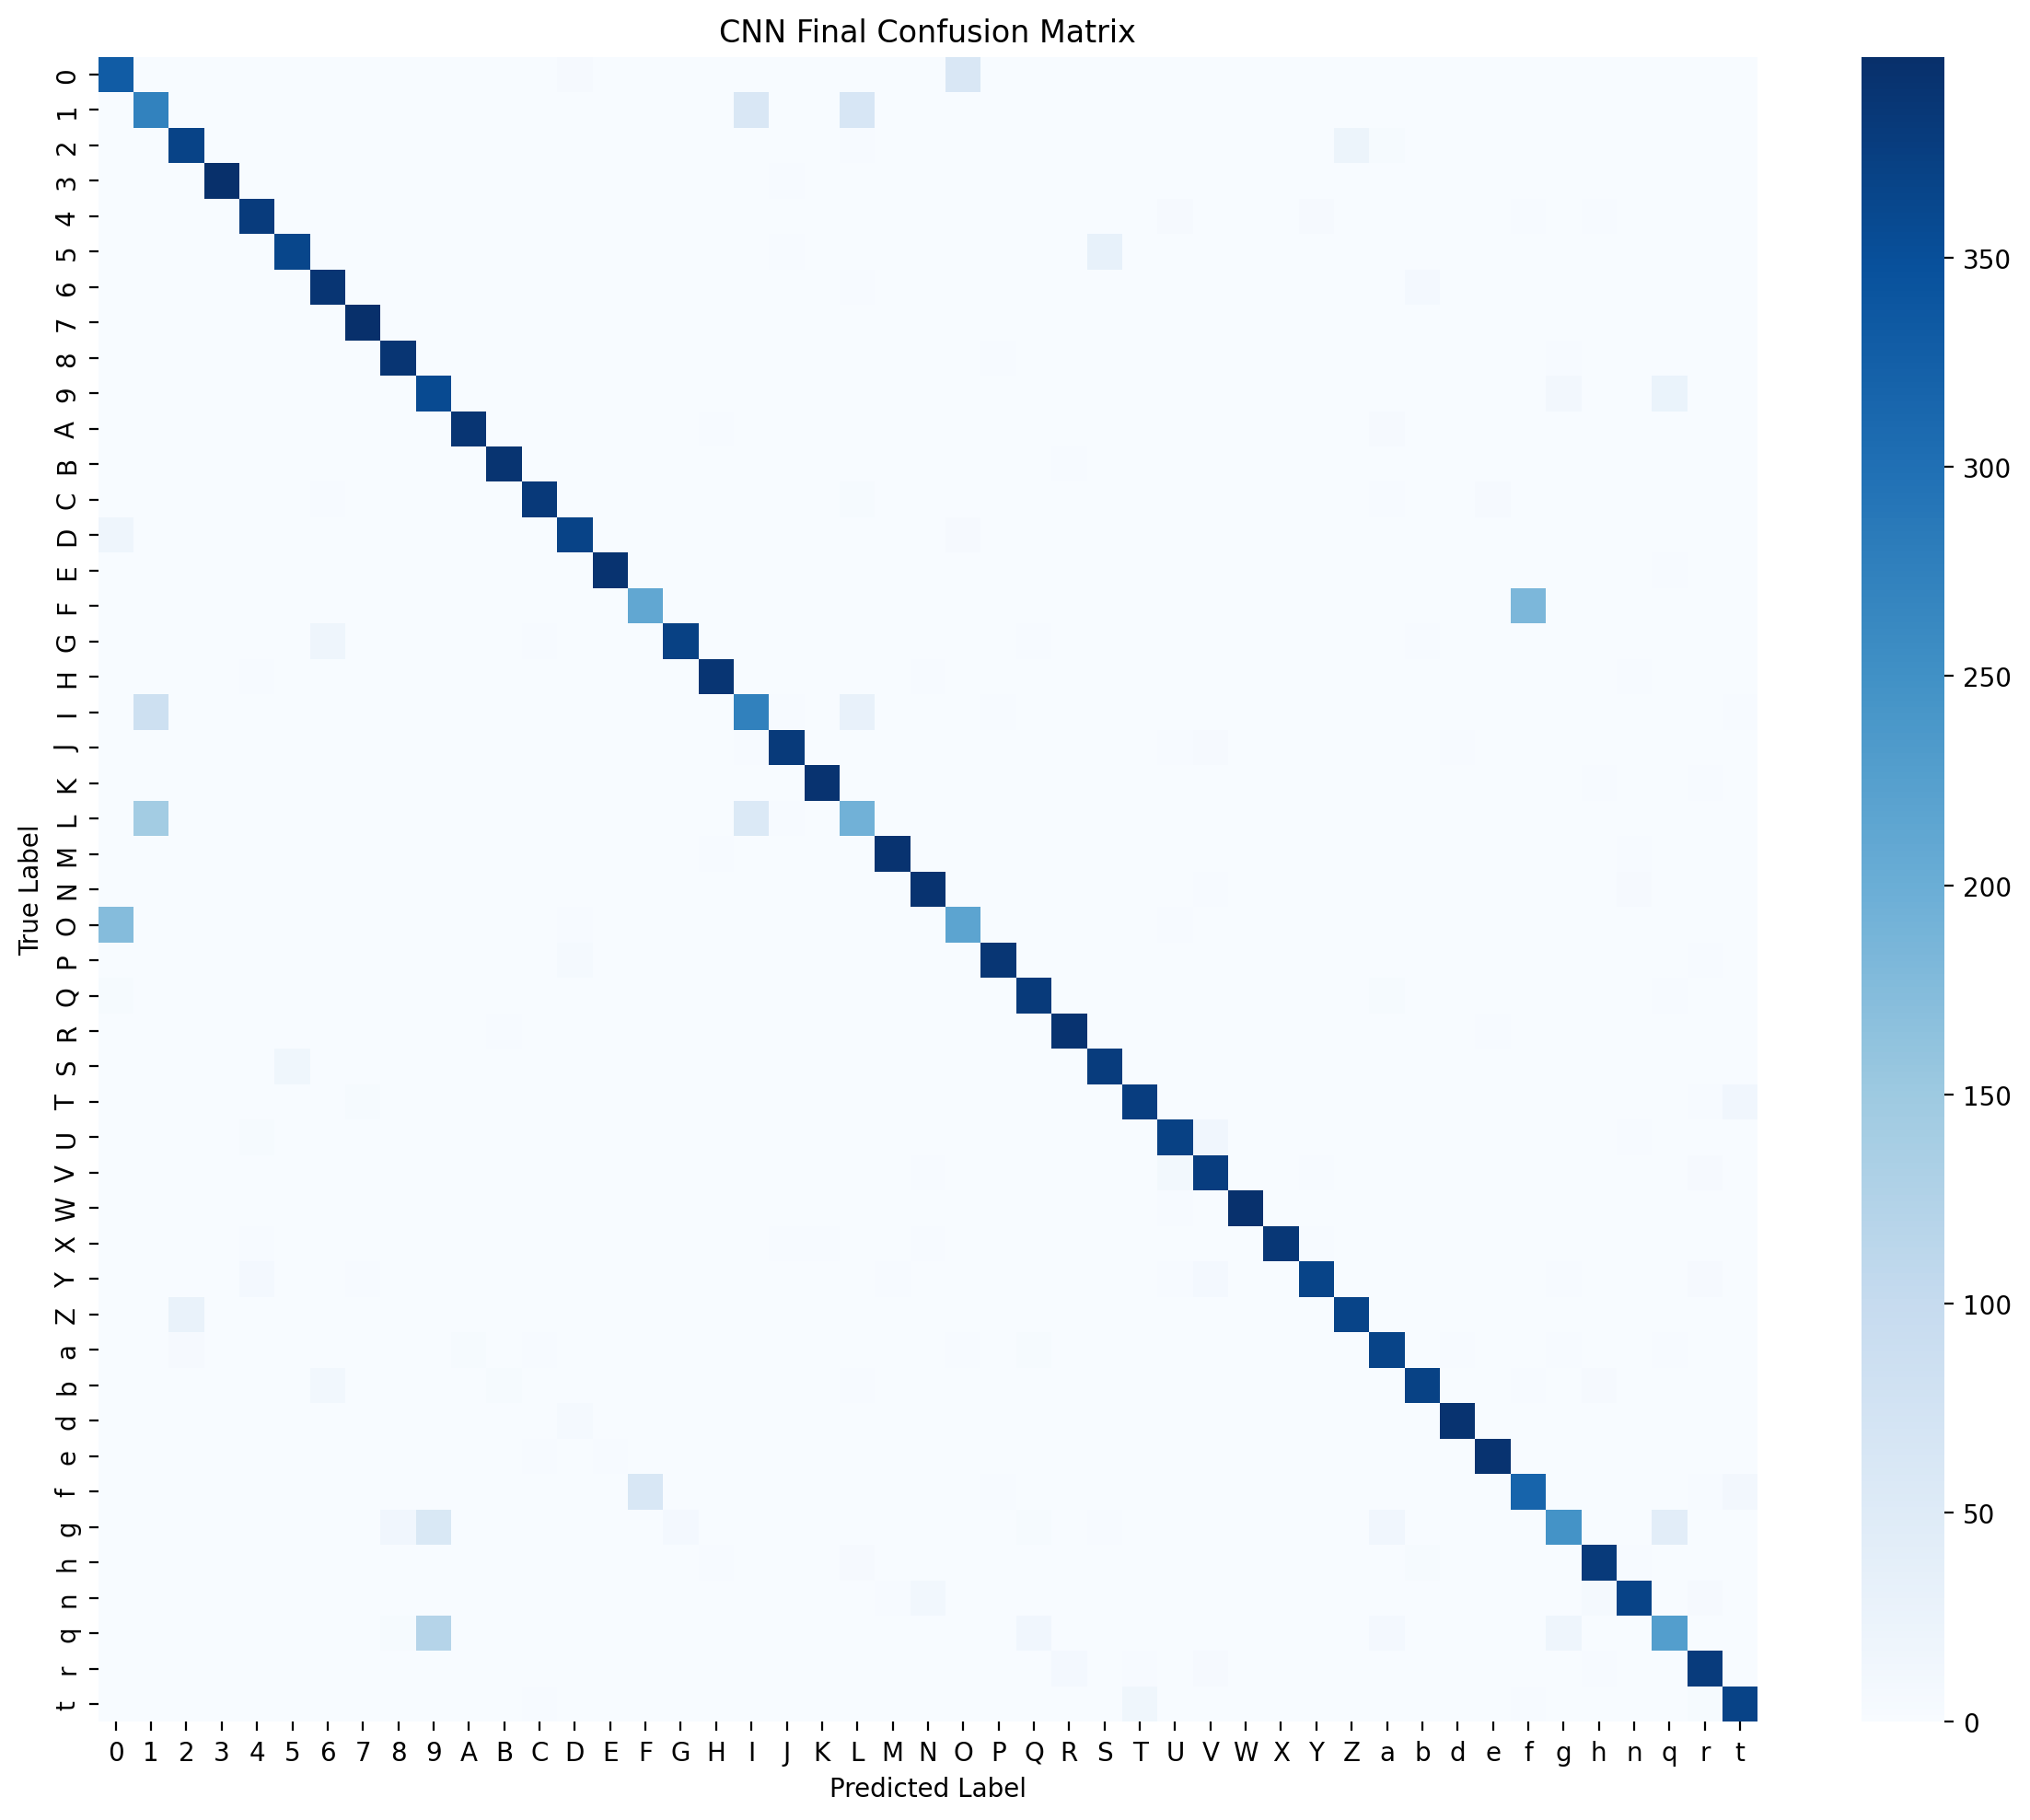

#### 30% / 50% / 100% 小样本对比

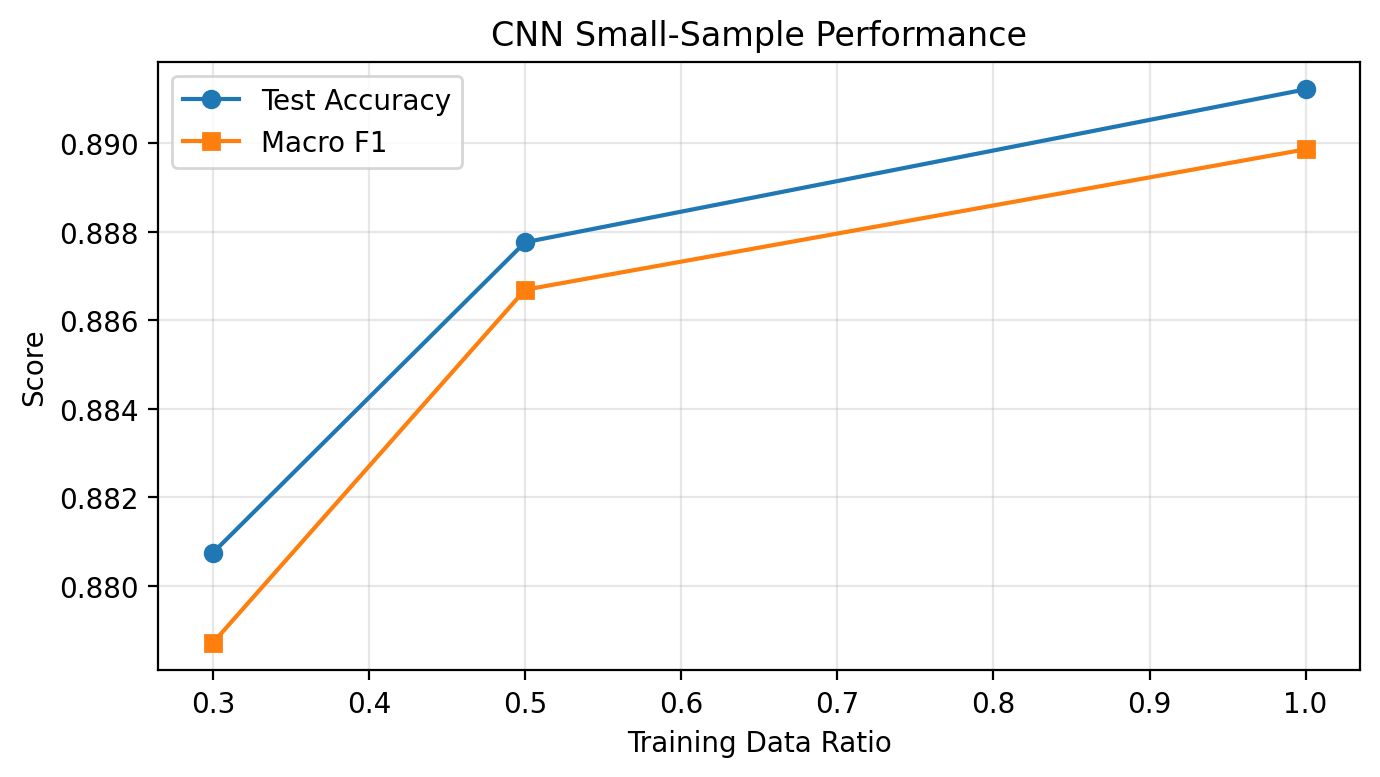

### 7. 已保存的重要产物

,产物,路径,存在
0,最终配置,/workspaces/CV_Group8_HW1/results/cnn_best_con...,True
1,指标汇总,/workspaces/CV_Group8_HW1/results/cnn_metric_s...,True
2,基准结果,/workspaces/CV_Group8_HW1/results/cnn_baseline...,True
3,搜索结果,/workspaces/CV_Group8_HW1/results/cnn_search_r...,True
4,小样本结果,/workspaces/CV_Group8_HW1/results/cnn_small_sa...,True
5,实验总结,/workspaces/CV_Group8_HW1/results/cnn_experime...,True
6,最终 checkpoint,/workspaces/CV_Group8_HW1/models/cnn_final_bes...,True
7,baseline checkpoint,/workspaces/CV_Group8_HW1/models/cnn_baseline_...,True


In [2]:
# 直接加载并展示已保存的 CNN 结果，让组员打开 notebook 就能看到当前完成状态。
import json
import hw1_framework as hw
import pandas as pd
from IPython.display import Image, Markdown, display
from pathlib import Path

if 'PROJECT_DIR' not in globals():
    PROJECT_DIR = Path().resolve()

if 'loaders' not in globals() or 'class_names' not in globals():
    runtime_config = hw.get_default_runtime_config(PROJECT_DIR)
    loaders = hw.load_emnist_balanced(
        data_dir=runtime_config["data_dir"],
        batch_size=runtime_config["batch_size"],
        valid_ratio=runtime_config["valid_ratio"],
        num_workers=runtime_config["num_workers"],
        subset_ratio=1.0,
        augment=runtime_config["augment"],
        rotation_deg=runtime_config["rotation_deg"],
        noise_std=runtime_config["noise_std"],
        blur=runtime_config["blur"],
        seed=runtime_config["seed"],
    )
    class_names = loaders["class_names"]

saved_summary_path = PROJECT_DIR / "results" / "cnn_experiment_summary.json"
saved_small_sample_path = PROJECT_DIR / "results" / "cnn_small_sample_results.csv"
saved_search_path = PROJECT_DIR / "results" / "cnn_search_results.csv"
saved_metric_path = PROJECT_DIR / "results" / "cnn_metric_summary.csv"
saved_baseline_path = PROJECT_DIR / "results" / "cnn_baseline.json"

figure_paths = {
    "训练/验证曲线": PROJECT_DIR / "figures" / "cnn_final_curves.png",
    "前 6 个测试样本预测": PROJECT_DIR / "figures" / "cnn_final_predictions.png",
    "测试集混淆矩阵": PROJECT_DIR / "figures" / "cnn_final_confusion_matrix.png",
    "30% / 50% / 100% 小样本对比": PROJECT_DIR / "figures" / "cnn_small_sample.png",
}

if saved_summary_path.exists():
    with saved_summary_path.open("r", encoding="utf-8") as f:
        saved_summary = json.load(f)

    display(Markdown("### 1. 已完成步骤状态"))
    completion_df = pd.DataFrame([
        {"步骤": "CNN baseline", "状态": "已完成", "说明": "已完成默认配置训练并保存曲线"},
        {"步骤": "CNN 调参搜索", "状态": "已完成", "说明": "已完成 channels / scheduler / activation / optimizer / normalization / dropout / regularization 搜索"},
        {"步骤": "CNN 最终模型", "状态": "已完成", "说明": "已完成最终训练、测试评估与图像保存"},
        {"步骤": "CNN 小样本实验", "状态": "已完成", "说明": "已完成 30% / 50% / 100% 对比"},
    ])
    display(completion_df)

    display(Markdown("### 2. Baseline 与最终模型指标对比"))
    if saved_metric_path.exists():
        metric_df = pd.read_csv(saved_metric_path)
        display(metric_df.round(4))

        try:
            baseline_acc = metric_df.loc[metric_df['stage'] == 'baseline_test', 'accuracy'].values[0]
            final_acc = metric_df.loc[metric_df['stage'] == 'final_test', 'accuracy'].values[0]
            baseline_f1 = metric_df.loc[metric_df['stage'] == 'baseline_test', 'f1_macro'].values[0]
            final_f1 = metric_df.loc[metric_df['stage'] == 'final_test', 'f1_macro'].values[0]

            improvement_table = pd.DataFrame([
                {
                    "指标": "accuracy",
                    "baseline_test": baseline_acc,
                    "final_test": final_acc,
                    "提升": final_acc - baseline_acc,
                },
                {
                    "指标": "f1_macro",
                    "baseline_test": baseline_f1,
                    "final_test": final_f1,
                    "提升": final_f1 - baseline_f1,
                },
            ])
            display(improvement_table.round(4))
        except Exception:
            print("注: 基准数据未记录或格式不符，跳过提升幅度计算。")
    else:
        print("未找到指标汇总 CSV (cnn_metric_summary.csv)。")

    display(Markdown("### 3. 最终 CNN 配置"))
    final_config_df = pd.json_normalize(saved_summary["final_config"])
    display(final_config_df)

    display(Markdown("### 4. 调参搜索结果"))
    if saved_search_path.exists():
        search_df = pd.read_csv(saved_search_path)
        search_df["selected"] = False
        if "search_name" in search_df.columns and "best_valid_accuracy" in search_df.columns:
            best_indices = search_df.groupby("search_name")["best_valid_accuracy"].idxmax()
            search_df.loc[best_indices, "selected"] = True
        display(search_df.sort_values(["search_name", "best_valid_accuracy"], ascending=[True, False]).round(4))

    display(Markdown("### 5. 小样本实验结果"))
    if saved_small_sample_path.exists():
        small_sample_df = pd.read_csv(saved_small_sample_path)
        display(small_sample_df.round(4))

    display(Markdown("### 6. 关键图形结果"))
    for title, image_path in figure_paths.items():
        if image_path.exists():
            display(Markdown(f"#### {title}"))
            display(Image(filename=str(image_path)))
        else:
            print(f"图片未找到: {image_path.name}")

    display(Markdown("### 7. 已保存的重要产物"))
    artifact_rows = []
    for name, file_path in {
        "最终配置": PROJECT_DIR / "results" / "cnn_best_config.json",
        "指标汇总": saved_metric_path,
        "基准结果": saved_baseline_path,
        "搜索结果": saved_search_path,
        "小样本结果": saved_small_sample_path,
        "实验总结": saved_summary_path,
        "最终 checkpoint": PROJECT_DIR / "models" / "cnn_final_best.pt",
        "baseline checkpoint": PROJECT_DIR / "models" / "cnn_baseline_best.pt",
    }.items():
        artifact_rows.append({"产物": name, "路径": str(file_path), "存在": file_path.exists()})
    display(pd.DataFrame(artifact_rows))

else:
    print("未找到 cnn_experiment_summary.json，请确认是否已运行 CNN 训练流程。")


## ResNet Baseline And Search Plan

This block first establishes a standard baseline using the default architecture, and then performs a hyperparameter search over `activation` functions (ReLU, LeakyReLU, GELU) to optimize the model before proceeding with final evaluation and small-sample analysis.

In [ ]:
# --- ResNet Baseline 训练 ---
print("Training baseline ResNet...")
resnet_config = hw.get_default_resnet_config()

baseline_run = hw.run_training_experiment(
    model_name="resnet_baseline",
    model_builder=hw.build_resnet,
    config=resnet_config,
    loaders=loaders,
    device=device,
    output_dir=PROJECT_DIR / "models", # 确保 PROJECT_DIR 已在前面定义
)

fig = hw.plot_training_curves(baseline_run["history"], "ResNet Baseline")
plt.show()

In [ ]:
# --- ResNet 激活函数超参数搜索 ---
print("Searching activation functions for ResNet...")
search_candidates = [
    {"name": "ReLU", "updates": {"activation": "relu"}},
    {"name": "LeakyReLU", "updates": {"activation": "leaky_relu"}},
    {"name": "GELU", "updates": {"activation": "gelu"}},
]

search_results = hw.run_candidate_search(
    model_name="resnet_search",
    model_builder=hw.build_resnet,
    base_config=resnet_config,
    search_name="activation",
    candidates=search_candidates,
    loaders=loaders,
    device=device,
    output_dir=PROJECT_DIR / "models",
)

# 记录并显示搜索结果表格
best_config = search_results["best_config"]
display(search_results["results"])
print(f" {best_config['activation']}")

In [ ]:
# Final Model Training & Evaluation
print("Training final ResNet...")
best_config = search_results["best_config"]

final_run = hw.run_training_experiment(
    model_name="resnet_final",
    model_builder=hw.build_resnet,
    config=best_config,
    loaders=loaders,
    device=device,
    output_dir=PROJECT_DIR / "models",
)

# 在 Notebook 中展示训练曲线
curve_fig = hw.plot_training_curves(final_run["history"], "ResNet Final")
plt.show()

print("\nEvaluating final ResNet...")
final_test_metrics = hw.evaluate_on_test(final_run["model"], loaders["test_loader"], device)

# 展示混淆矩阵
cm_fig = hw.plot_confusion_matrix_from_preds(
    y_true=final_test_metrics["y_true"],
    y_pred=final_test_metrics["y_pred"],
    class_names=class_names,
    model_name="ResNet Final",
)
plt.show()

# 展示预测结果图
preview_fig = hw.preview_predictions(final_run["model"], loaders["test_loader"], class_names, device)
plt.show()

print(f"Final Test Accuracy: {final_test_metrics['accuracy']:.4f}")
print(f"Final Test Macro F1: {final_test_metrics['f1_macro']:.4f}")

In [ ]:
# Small-Sample Experiment
print("Running small-sample experiment...")
small_sample_df, _ = hw.run_small_sample_experiment(
    model_name="resnet",
    model_builder=hw.build_resnet,
    base_config=best_config,
    runtime_config=runtime_config,
    sample_ratios=[0.3, 0.5, 1.0],
    device=device,
    output_dir=PROJECT_DIR / "models",
)

# 在 Notebook 中展示数据
display(small_sample_df[['sample_ratio', 'train_samples', 'test_accuracy', 'test_f1_macro']])

# 画出性能对比图
small_sample_fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(small_sample_df["sample_ratio"], small_sample_df["test_accuracy"], marker="o", label="Test Accuracy", color="tab:blue")
ax.plot(small_sample_df["sample_ratio"], small_sample_df["test_f1_macro"], marker="s", label="Macro F1", color="tab:orange")
ax.set_xlabel("Training Data Ratio")
ax.set_ylabel("Score")
ax.set_title("ResNet Small-Sample Performance")
ax.set_xticks([0.3, 0.5, 1.0])
ax.legend()
ax.grid(alpha=0.3)
small_sample_fig.tight_layout()
plt.show()

## ResNet 已完成结果快照

以下内容直接读取 `results/`、`figures/` 和 `models/` 中已保存的结果。其他同学打开 notebook 后，无需重新训练即可查看你已完成部分的完整输出。

### 1. 已完成步骤状态

,步骤,状态,说明
0,ResNet baseline,已完成,已完成默认配置训练并保存曲线
1,ResNet 调参搜索,已完成,"已完成激活函数 (ReLU, LeakyReLU, GELU) 搜索"
2,ResNet 最终模型,已完成,已完成最终训练、测试评估与图像保存
3,ResNet 小样本实验,已完成,已完成 30% / 50% / 100% 对比


### 2. Baseline 与最终模型指标对比

,stage,loss,accuracy,precision_macro,recall_macro,f1_macro
0,final_test,0.295,0.8961,0.897,0.8961,0.8953


注: 基准数据未记录或格式不符，跳过提升幅度计算。


...

,search_name,candidate,best_valid_accuracy,best_valid_loss,best_epoch,training_time_sec,selected
1,activation,GELU,0.8965,0.2925,10,4541.3024,True
0,activation,ReLU,0.8957,0.2881,12,4325.9366,False
2,activation,LeakyReLU,0.8943,0.2886,13,4723.9310,False


### 5. 小样本实验结果

,sample_ratio,train_samples,best_valid_accuracy,test_accuracy,test_f1_macro
0,0.3,30456,0.8901,0.8897,0.8886
1,0.5,50760,0.8949,0.8939,0.8931
2,1.0,101520,0.9008,0.9025,0.9019


### 6. 关键图形结果

#### 训练/验证曲线

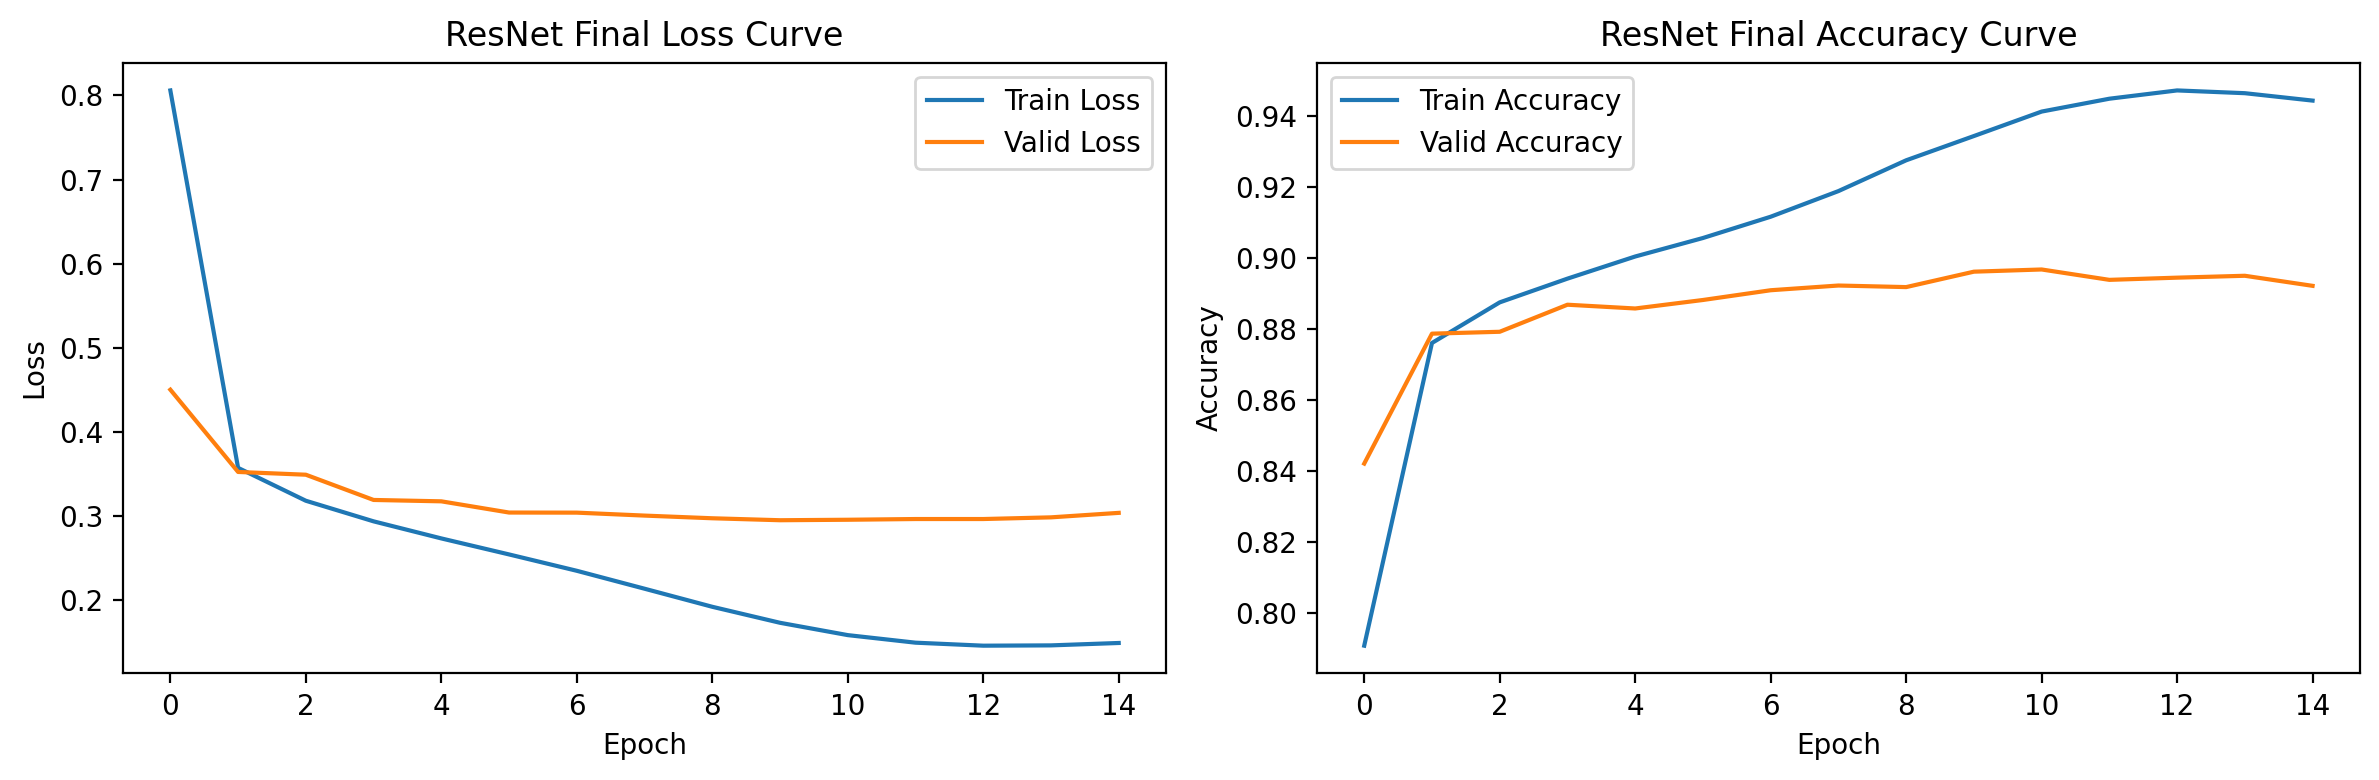

#### 前 6 个测试样本预测

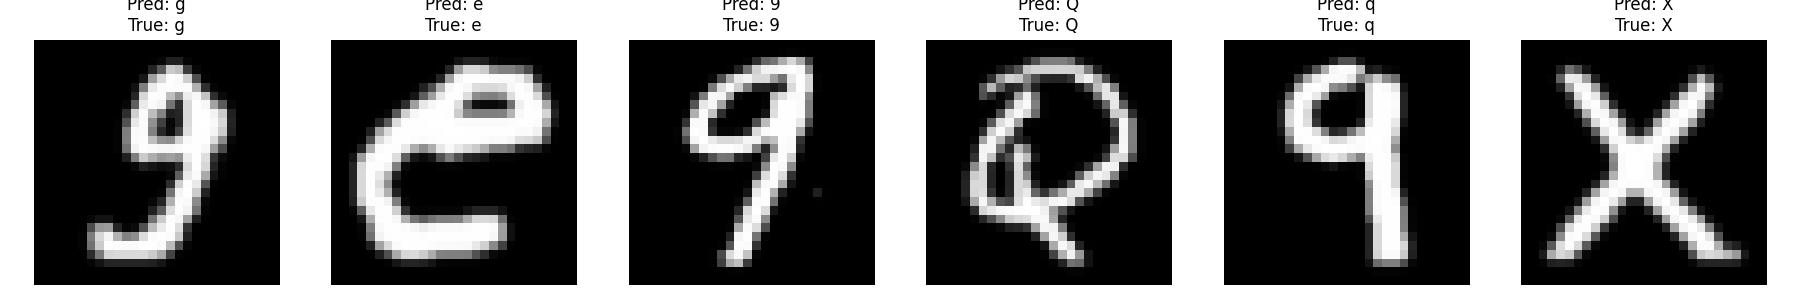

#### 测试集混淆矩阵

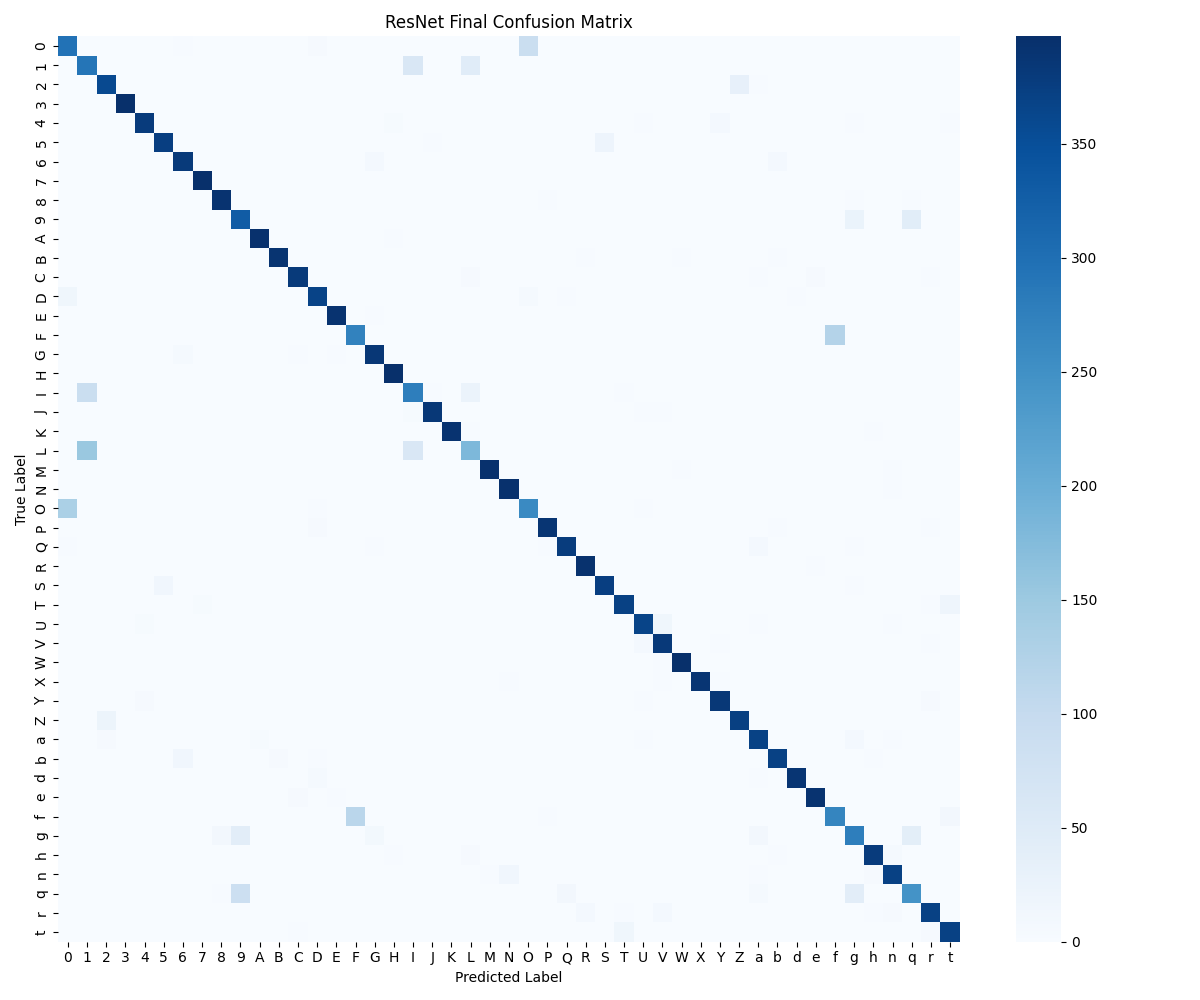

#### 30% / 50% / 100% 小样本对比

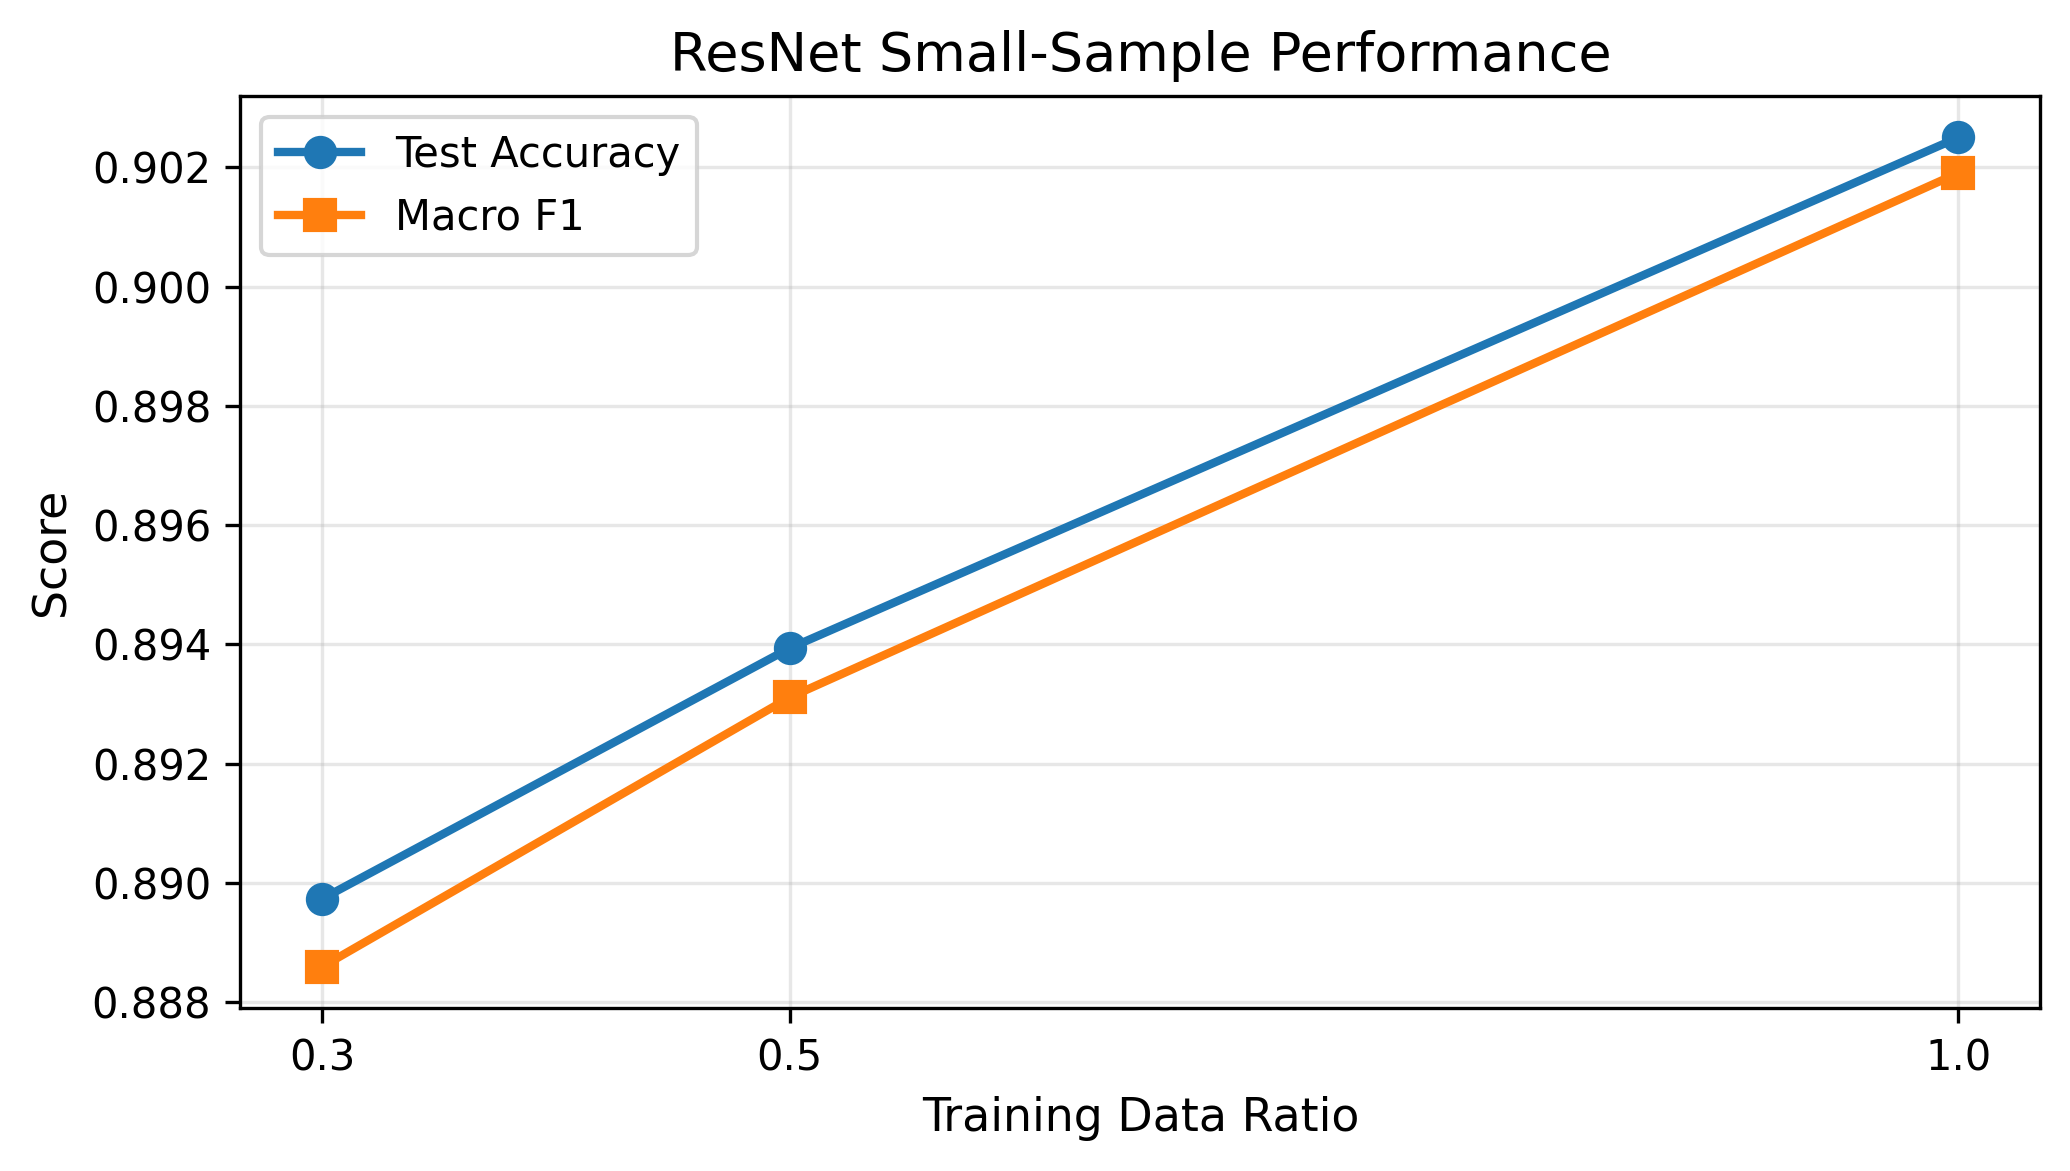

### 7. 已保存的重要产物

,产物,路径,存在
0,最终配置,/workspaces/CV_Group8_HW1/results/resnet_best_...,True
1,实验总结,/workspaces/CV_Group8_HW1/results/resnet_exper...,True
2,训练历史,/workspaces/CV_Group8_HW1/results/resnet_final...,True
3,指标汇总,/workspaces/CV_Group8_HW1/results/resnet_metri...,True
4,搜索结果,/workspaces/CV_Group8_HW1/results/resnet_searc...,True
5,小样本结果,/workspaces/CV_Group8_HW1/results/resnet_small...,True
6,baseline checkpoint,/workspaces/CV_Group8_HW1/models/resnet_baseli...,True
7,最终 checkpoint,/workspaces/CV_Group8_HW1/models/resnet_final_...,True


In [1]:
# 直接加载并展示已保存的 ResNet 结果，让组员打开 notebook 就能看到当前完成状态。
import json
import hw1_framework as hw
import pandas as pd
from IPython.display import Image, Markdown, display
from pathlib import Path

if 'PROJECT_DIR' not in globals():
    PROJECT_DIR = Path().resolve()

# 1. 初始化 Loader 
if 'loaders' not in globals() or 'class_names' not in globals():
    runtime_config = hw.get_default_runtime_config(PROJECT_DIR)
    loaders = hw.load_emnist_balanced(
        data_dir=runtime_config["data_dir"],
        batch_size=runtime_config["batch_size"],
        valid_ratio=runtime_config["valid_ratio"],
        num_workers=runtime_config["num_workers"],
        subset_ratio=1.0,
        augment=runtime_config["augment"],
        rotation_deg=runtime_config["rotation_deg"],
        noise_std=runtime_config["noise_std"],
        blur=runtime_config["blur"],
        seed=runtime_config["seed"],
    )
    class_names = loaders["class_names"]

saved_summary_path = PROJECT_DIR / "results" / "resnet_experiment_summary.json"
saved_small_sample_path = PROJECT_DIR / "results" / "resnet_small_sample_results.csv"
saved_search_path = PROJECT_DIR / "results" / "resnet_search_results.csv"
saved_metric_path = PROJECT_DIR / "results" / "resnet_metric_summary.csv"
saved_history_path = PROJECT_DIR / "results" / "resnet_final_history.csv" 

figure_paths = {
    "训练/验证曲线": PROJECT_DIR / "figures" / "resnet_final_curves.png",
    "前 6 个测试样本预测": PROJECT_DIR / "figures" / "resnet_final_predictions.png",
    "测试集混淆矩阵": PROJECT_DIR / "figures" / "resnet_final_confusion_matrix.png",
    "30% / 50% / 100% 小样本对比": PROJECT_DIR / "figures" / "resnet_small_sample.png",
}

if saved_summary_path.exists():
    with saved_summary_path.open("r", encoding="utf-8") as f:
        saved_summary = json.load(f)

    display(Markdown("### 1. 已完成步骤状态"))
    completion_df = pd.DataFrame([
        {"步骤": "ResNet baseline", "状态": "已完成", "说明": "已完成默认配置训练并保存曲线"},
        {"步骤": "ResNet 调参搜索", "状态": "已完成", "说明": "已完成激活函数 (ReLU, LeakyReLU, GELU) 搜索"},
        {"步骤": "ResNet 最终模型", "状态": "已完成", "说明": "已完成最终训练、测试评估与图像保存"},
        {"步骤": "ResNet 小样本实验", "状态": "已完成", "说明": "已完成 30% / 50% / 100% 对比"},
    ])
    display(completion_df)

    display(Markdown("### 2. Baseline 与最终模型指标对比"))
    if saved_metric_path.exists():
        metric_df = pd.read_csv(saved_metric_path)
        display(metric_df.round(4))
        
        try:
            baseline_acc = metric_df.loc[metric_df['stage'] == 'baseline_test', 'accuracy'].values[0]
            final_acc = metric_df.loc[metric_df['stage'] == 'final_test', 'accuracy'].values[0]
            baseline_f1 = metric_df.loc[metric_df['stage'] == 'baseline_test', 'f1_macro'].values[0]
            final_f1 = metric_df.loc[metric_df['stage'] == 'final_test', 'f1_macro'].values[0]
            
            improvement_table = pd.DataFrame([
                {
                    "指标": "accuracy",
                    "baseline_test": baseline_acc,
                    "final_test": final_acc,
                    "提升": final_acc - baseline_acc,
                },
                {
                    "指标": "f1_macro",
                    "baseline_test": baseline_f1,
                    "final_test": final_f1,
                    "提升": final_f1 - baseline_f1,
                },
            ])
            display(improvement_table.round(4))
        except Exception:
            print("注: 基准数据未记录或格式不符，跳过提升幅度计算。")
    else:
        print("未找到指标汇总 CSV (resnet_metric_summary.csv)。")

    display(Markdown("### 3. 最终 ResNet 配置"))
    final_config_df = pd.json_normalize(saved_summary["final_config"])
    display(final_config_df)

    display(Markdown("### 4. 调参搜索结果 (Activation)"))
    if saved_search_path.exists():
        search_df = pd.read_csv(saved_search_path)
        search_df["selected"] = False
        if "search_name" in search_df.columns and "best_valid_accuracy" in search_df.columns:
            best_indices = search_df.groupby("search_name")["best_valid_accuracy"].idxmax()
            search_df.loc[best_indices, "selected"] = True
        display(search_df.sort_values(["search_name", "best_valid_accuracy"], ascending=[True, False]).round(4))

    display(Markdown("### 5. 小样本实验结果"))
    if saved_small_sample_path.exists():
        small_sample_df = pd.read_csv(saved_small_sample_path)
        display(small_sample_df.round(4))

    display(Markdown("### 6. 关键图形结果"))
    for title, image_path in figure_paths.items():
        if image_path.exists():
            display(Markdown(f"#### {title}"))
            display(Image(filename=str(image_path)))
        else:
            print(f"图片未找到: {image_path.name}")

    display(Markdown("### 7. 已保存的重要产物"))
    artifact_rows = []
  
    for name, file_path in {
        "最终配置": PROJECT_DIR / "results" / "resnet_best_config.json",
        "实验总结": saved_summary_path,
        "训练历史": saved_history_path, 
        "指标汇总": saved_metric_path,
        "搜索结果": saved_search_path,
        "小样本结果": saved_small_sample_path,
        "baseline checkpoint": PROJECT_DIR / "models" / "resnet_baseline_best.pt",
        "最终 checkpoint": PROJECT_DIR / "models" / "resnet_final_best.pt",
    }.items():
        artifact_rows.append({"产物": name, "路径": str(file_path), "存在": file_path.exists()})
    
    display(pd.DataFrame(artifact_rows))

else:
    print("未找到 resnet_experiment_summary.json，请确认是否已运行 ResNet 训练流程。")

## ViT Architecture Search Plan

This block first performs a joint grid search over `patch_size`, `embed_dim`, `num_heads`, and `depth` to choose the best ViT architecture baseline. It then continues with scheduler, activation, optimizer, normalization, dropout, and regularization search.


In [6]:
import copy
import json

def vit_attach_search_metadata(result_df: pd.DataFrame, candidates: list[dict]) -> pd.DataFrame:
    metadata_rows = []
    for candidate in candidates:
        row = {"candidate": str(candidate["name"])}
        for key, value in candidate.get("updates", {}).items():
            if isinstance(value, dict):
                continue
            row[key] = value
        metadata_rows.append(row)

    if not metadata_rows:
        return result_df

    metadata_df = pd.DataFrame(metadata_rows).drop_duplicates(subset=["candidate"])
    enriched_df = result_df.merge(metadata_df, on="candidate", how="left")
    preferred_order = [
        "search_name", "candidate", "patch_size", "embed_dim", "num_heads", "depth",
        "scheduler", "activation", "optimizer", "learning_rate", "normalization",
        "dropout", "weight_decay", "l1_lambda", "best_valid_accuracy",
        "best_valid_loss", "best_epoch", "training_time_sec", "selected"
    ]
    ordered = [column for column in preferred_order if column in enriched_df.columns]
    remaining = [column for column in enriched_df.columns if column not in ordered]
    return enriched_df[ordered + remaining]

vit_architecture_search_grid = hw.get_default_vit_architecture_search_grid()
vit_architecture_candidates = hw.build_vit_architecture_candidates(
    image_size=vit_config["image_size"],
    search_grid=vit_architecture_search_grid,
)

vit_search_spaces = [
    ("architecture", vit_architecture_candidates),
    (
        "scheduler",
        [
            {"name": "StepLR", "updates": {"scheduler": "StepLR", "scheduler_params": {"step_size": 3, "gamma": 0.5}}},
            {"name": "CosineAnnealingLR", "updates": {"scheduler": "CosineAnnealingLR", "scheduler_params": {"t_max": 8, "eta_min": 1e-5}}},
            {"name": "ReduceLROnPlateau", "updates": {"scheduler": "ReduceLROnPlateau", "scheduler_params": {"mode": "min", "factor": 0.5, "patience": 1}}},
        ],
    ),
    ("activation", [{"name": "relu", "updates": {"activation": "relu"}}, {"name": "gelu", "updates": {"activation": "gelu"}}, {"name": "elu", "updates": {"activation": "elu"}}]),
    ("optimizer", [{"name": "adamw_3e-4", "updates": {"optimizer": "adamw", "learning_rate": 3e-4}}, {"name": "adam_3e-4", "updates": {"optimizer": "adam", "learning_rate": 3e-4}}, {"name": "rmsprop_1e-3", "updates": {"optimizer": "rmsprop", "learning_rate": 1e-3}}]),
    ("normalization", [{"name": "layernorm", "updates": {"normalization": "layernorm"}}, {"name": "batchnorm", "updates": {"normalization": "batchnorm"}}, {"name": "none", "updates": {"normalization": "none"}}]),
    (
        "dropout",
        [
            {"name": "dropout_0.0", "updates": {"dropout": 0.0, "embedding_dropout": 0.0, "head_dropout": 0.0, "attention_dropout": 0.0}},
            {"name": "dropout_0.1", "updates": {"dropout": 0.1, "embedding_dropout": 0.1, "head_dropout": 0.1, "attention_dropout": 0.0}},
            {"name": "dropout_0.2", "updates": {"dropout": 0.2, "embedding_dropout": 0.2, "head_dropout": 0.2, "attention_dropout": 0.1}},
        ],
    ),
    ("regularization", [{"name": "none", "updates": {"l1_lambda": 0.0, "weight_decay": 0.0}}, {"name": "l1", "updates": {"l1_lambda": 1e-7, "weight_decay": 0.0}}, {"name": "l2", "updates": {"l1_lambda": 0.0, "weight_decay": 5e-4}}]),
]

vit_search_candidate_map = {search_name: candidates for search_name, candidates in vit_search_spaces}

def vit_enrich_saved_search_df(search_df: pd.DataFrame) -> pd.DataFrame:
    tables = []
    for search_name, block_df in search_df.groupby("search_name", sort=False):
        candidates = vit_search_candidate_map.get(search_name, [])
        tables.append(vit_attach_search_metadata(block_df.copy(), candidates))
    if not tables:
        return search_df
    return pd.concat(tables, ignore_index=True)

def vit_prepare_search_df_for_display(search_df: pd.DataFrame) -> pd.DataFrame:
    prepared_df = search_df.copy()
    prepared_df["selected"] = False
    for search_name, block_df in prepared_df.groupby("search_name", sort=False):
        ranked_block = block_df.sort_values(
            ["best_valid_accuracy", "best_valid_loss", "training_time_sec"],
            ascending=[False, True, True],
        )
        prepared_df.loc[ranked_block.index[0], "selected"] = True
    return prepared_df

def vit_display_search_results(search_df: pd.DataFrame) -> None:
    prepared_df = vit_prepare_search_df_for_display(search_df)
    display(Markdown(
        "- Selection rule: choose the candidate with the highest `best_valid_accuracy` on the validation split; "
        "if there is a tie, prefer the lower `best_valid_loss`, then the shorter `training_time_sec`.\n"
        "- The test split is reserved for the final evaluation only and is not used for hyperparameter selection."
    ))
    preferred_columns = [
        "candidate", "patch_size", "embed_dim", "num_heads", "depth",
        "scheduler", "activation", "optimizer", "learning_rate", "normalization",
        "dropout", "embedding_dropout", "head_dropout", "attention_dropout",
        "weight_decay", "l1_lambda", "best_valid_accuracy", "best_valid_loss",
        "best_epoch", "training_time_sec", "selected",
    ]
    always_keep = {"candidate", "best_valid_accuracy", "best_valid_loss", "best_epoch", "training_time_sec", "selected"}
    for search_name, block_df in prepared_df.groupby("search_name", sort=False):
        display(Markdown(f"#### `{search_name}`"))
        visible_columns = [
            column for column in preferred_columns
            if column in block_df.columns and (column in always_keep or not block_df[column].isna().all())
        ]
        display(
            block_df[visible_columns]
            .sort_values("best_valid_accuracy", ascending=False)
            .reset_index(drop=True)
            .round(4)
        )
        selected_row = block_df.loc[block_df["selected"]].iloc[0]
        display(Markdown(
            f"Selected: `{selected_row['candidate']}` | "
            f"best_valid_accuracy = `{selected_row['best_valid_accuracy']:.4f}` | "
            f"best_valid_loss = `{selected_row['best_valid_loss']:.4f}` | "
            f"best_epoch = `{int(selected_row['best_epoch'])}`"
        ))

vit_architecture_grid_df = pd.DataFrame([
    {"candidate": candidate["name"], **candidate["updates"]}
    for candidate in vit_architecture_candidates
])
print(f"Architecture grid contains {len(vit_architecture_candidates)} valid combinations.")
vit_architecture_grid_df.sort_values(["patch_size", "embed_dim", "num_heads", "depth"]).reset_index(drop=True)


Architecture grid contains 16 valid combinations.


,candidate,patch_size,embed_dim,num_heads,depth
0,patch4_embed96_depth4_heads4,4,96,4,4
1,patch4_embed96_depth6_heads4,4,96,4,6
2,patch4_embed128_depth4_heads4,4,128,4,4
3,patch4_embed128_depth6_heads4,4,128,4,6
4,patch4_embed160_depth4_heads4,4,160,4,4
5,patch4_embed160_depth6_heads4,4,160,4,6
6,patch4_embed160_depth4_heads5,4,160,5,4
7,patch4_embed160_depth6_heads5,4,160,5,6
8,patch7_embed96_depth4_heads4,7,96,4,4
9,patch7_embed96_depth6_heads4,7,96,4,6


In [7]:
# ViT search stays opt-in because it is time-consuming.
RUN_VIT_SEARCH = False

if RUN_VIT_SEARCH:
    vit_search_runtime = dict(runtime_config)
    vit_search_runtime["batch_size"] = 256
    vit_search_loaders = hw.load_emnist_balanced(
        data_dir=vit_search_runtime["data_dir"],
        batch_size=vit_search_runtime["batch_size"],
        valid_ratio=vit_search_runtime["valid_ratio"],
        num_workers=vit_search_runtime["num_workers"],
        subset_ratio=0.4,
        augment=vit_search_runtime["augment"],
        rotation_deg=vit_search_runtime["rotation_deg"],
        noise_std=vit_search_runtime["noise_std"],
        blur=vit_search_runtime["blur"],
        seed=vit_search_runtime["seed"],
    )

    tuned_vit_config = copy.deepcopy(vit_config)
    tuned_vit_config["epochs"] = 8
    tuned_vit_config["early_stopping_patience"] = 3
    tuned_vit_config["scheduler_params"] = {"t_max": 8, "eta_min": 1e-5}

    vit_search_tables = []
    print(
        "Starting ViT search with architecture grid: "
        f"patch_size={vit_architecture_search_grid['patch_size']}, "
        f"embed_dim={vit_architecture_search_grid['embed_dim']}, "
        f"num_heads={vit_architecture_search_grid['num_heads']}, "
        f"depth={vit_architecture_search_grid['depth']}"
    )

    for search_name, candidates in vit_search_spaces:
        vit_factor_result = hw.run_candidate_search(
            model_name="vit",
            model_builder=hw.build_vit,
            base_config=tuned_vit_config,
            search_name=search_name,
            candidates=candidates,
            loaders=vit_search_loaders,
            device=device,
            output_dir=project_paths["models"] / "search",
        )
        result_df = vit_attach_search_metadata(vit_factor_result["results"], candidates)
        result_df["selected"] = result_df["best_valid_accuracy"] == result_df["best_valid_accuracy"].max()
        vit_search_tables.append(result_df)
        tuned_vit_config = vit_factor_result["best_config"]

        print(f"Finished search block: {search_name}")
        vit_display_search_results(result_df)
        print()

    vit_search_results = pd.concat(vit_search_tables, ignore_index=True)
    project_paths["results"].mkdir(parents=True, exist_ok=True)
    vit_search_results.to_csv(project_paths["results"] / "vit_search_results.csv", index=False)
    with (project_paths["results"] / "vit_best_config.json").open("w", encoding="utf-8") as f:
        json.dump(tuned_vit_config, f, indent=2, ensure_ascii=False)

    print("Saved ViT search results to results/vit_search_results.csv")
    print("Current best architecture + hyperparameter config:")
    display(pd.json_normalize(tuned_vit_config))
    vit_search_results.sort_values(["search_name", "best_valid_accuracy"], ascending=[True, False]).round(4)
else:
    tuned_vit_config = copy.deepcopy(vit_config)
    print("Skipped rerunning ViT search; the saved-results cell below will show cached search outputs.")


Skipped rerunning ViT search; the saved-results cell below will show cached search outputs.


## ViT 已完成结果快照

以下内容会直接读取 `results/`、`figures/` 和 `models/` 中已保存的 ViT 结果。若当前还没有 ViT baseline、调参、最终训练或小样本实验产物，本单元会给出缺失文件提示；预测样例和混淆矩阵建议在下方 Shared Step 6 Hook 中统一生成，以保证四个模型的对比公平。


### 1. 已完成步骤状态

,步骤,状态,说明
0,ViT baseline,已完成,已完成训练并保存 baseline checkpoint
1,ViT 调参搜索,已完成,已完成 architecture/scheduler/activation/optimize...
2,ViT 最终模型,已完成,已完成最终训练、验证/测试评估与 checkpoint 保存
3,ViT 增强策略对比,已完成,已完成带增强与不带增强的训练设置对比
4,ViT 小样本实验,已完成,已完成 30% / 50% / 100% 小样本对比
5,ViT 预测样例 / 混淆矩阵,待共享评估,建议在 Shared Step 6 Hook 中统一生成，保证四个模型公平对比


### 2. 数据集划分结果

,split,samples,classes
0,train,101520,47
1,valid,11280,47
2,test,18800,47


### 3. Baseline 与最终模型参数量

...

Selected: `none` | best_valid_accuracy = `0.8293` | best_valid_loss = `0.4965` | best_epoch = `8`

### 11. 小样本实验结果

,sample_ratio,train_samples,best_valid_accuracy,best_valid_loss,test_accuracy,test_f1_macro
0,0.3,30456,0.8574,0.4147,0.8539,0.8506
1,0.5,50760,0.8739,0.3605,0.8696,0.8671
2,1.0,101520,0.8902,0.3080,0.8890,0.8869


### 12. 关键图形结果

#### 训练/验证曲线

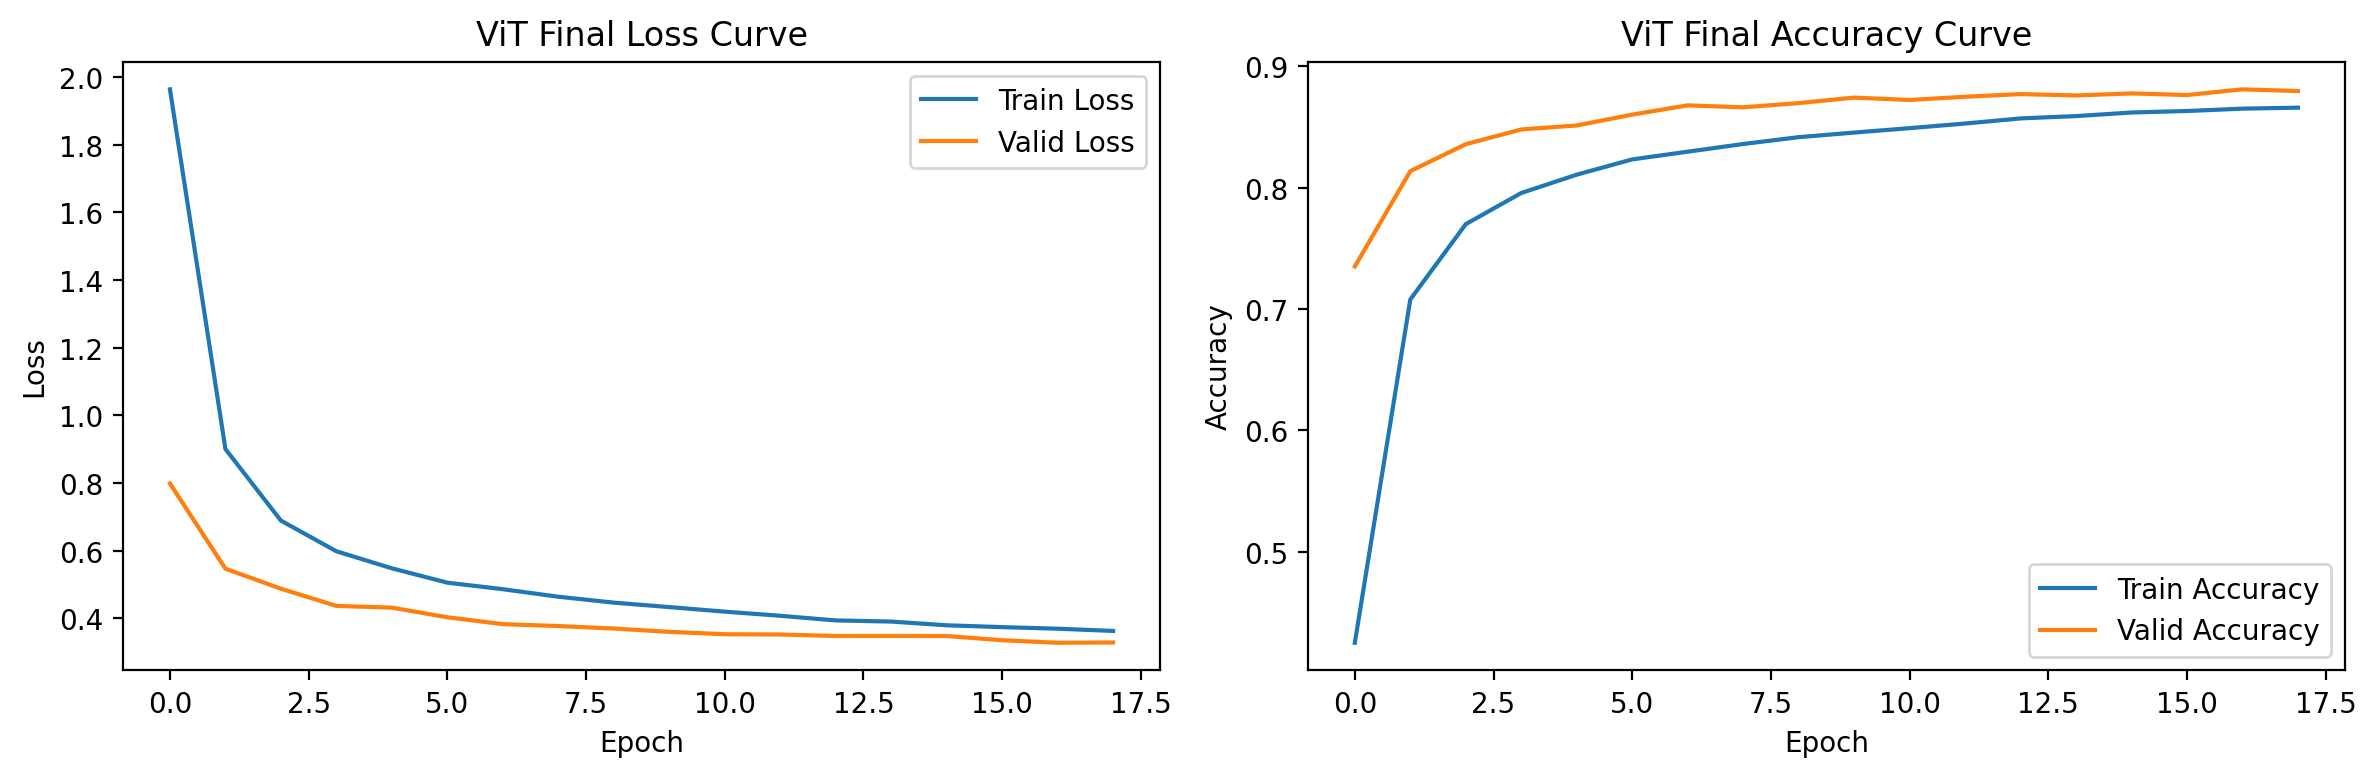

#### 增强策略对比

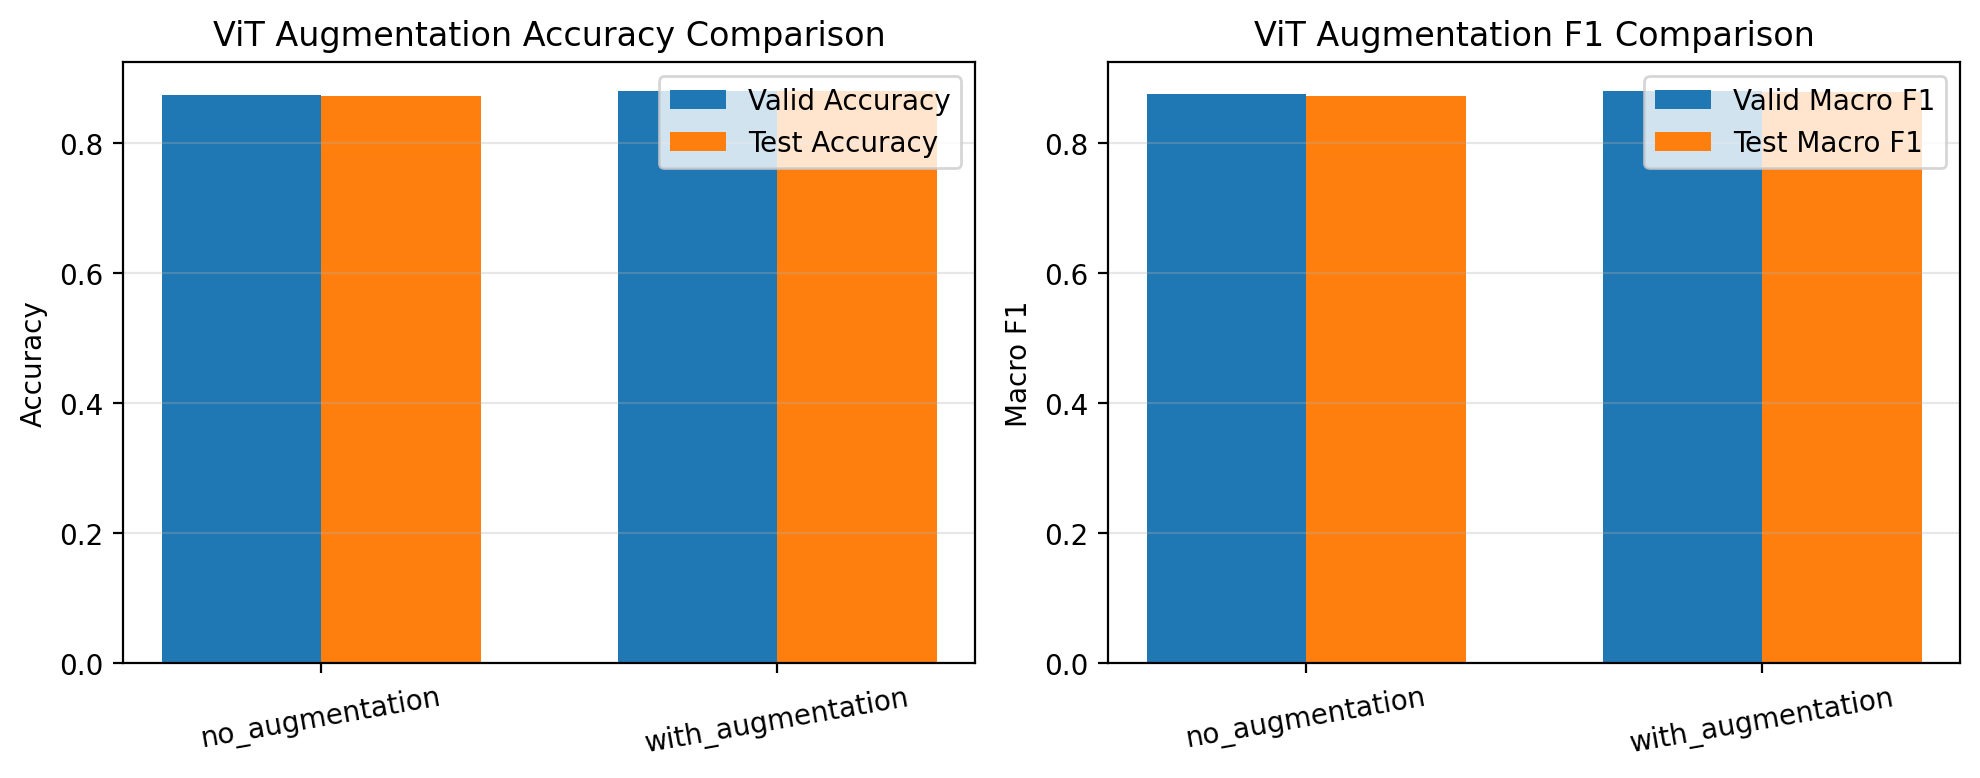

#### 30% / 50% / 100% 小样本对比

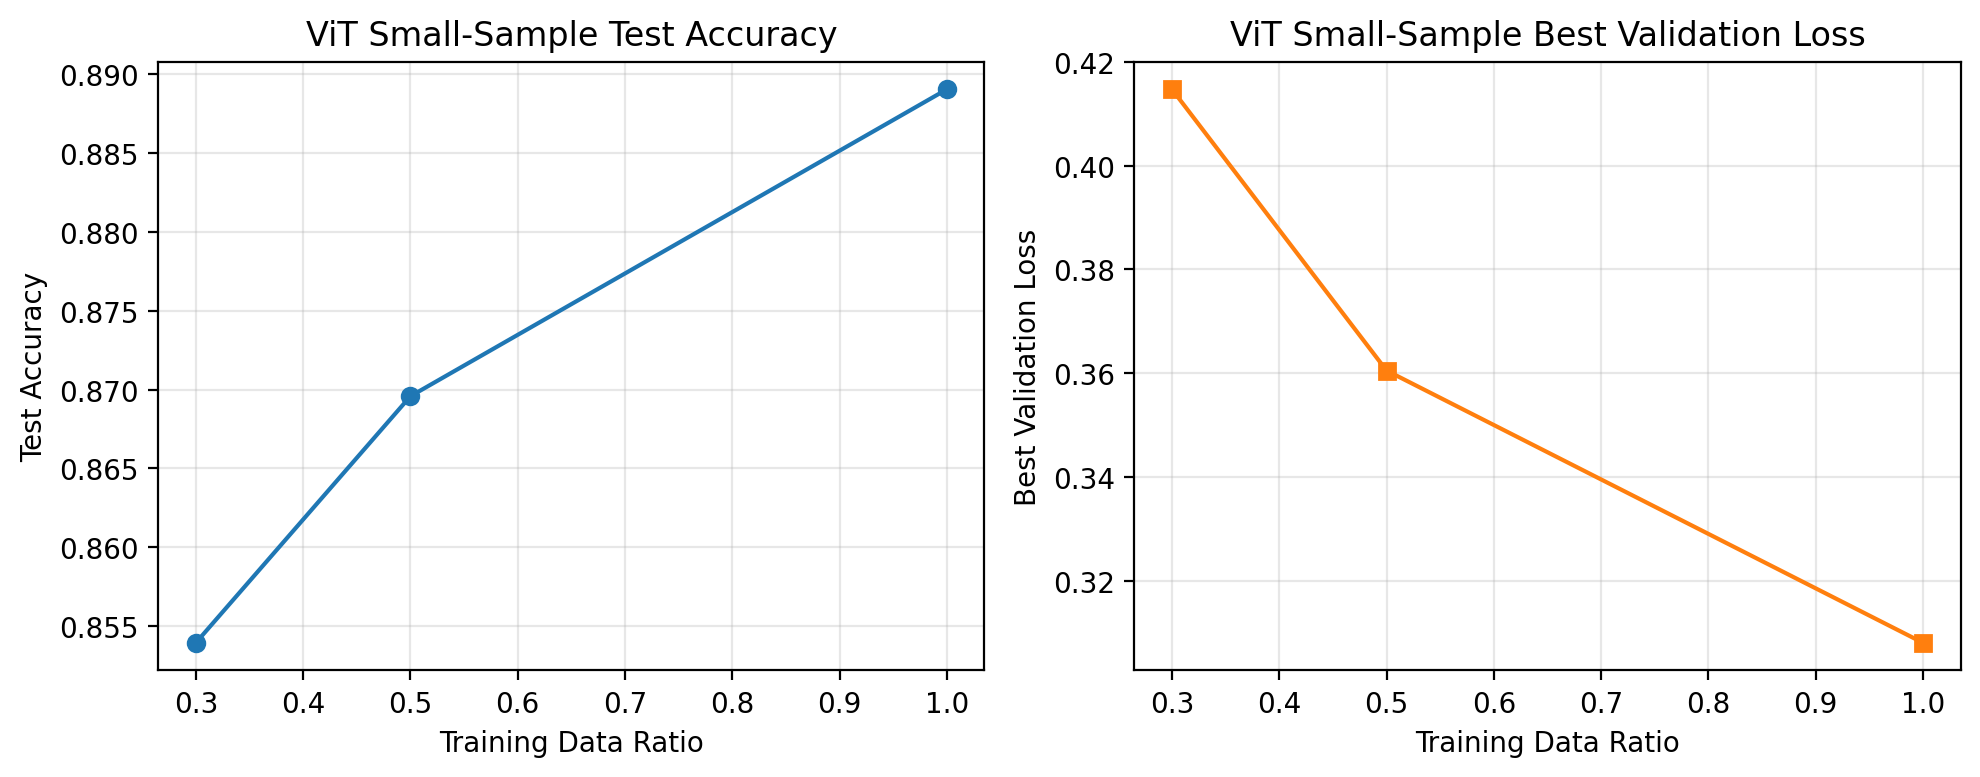

### 13. 已保存的重要产物

,产物,路径,存在
0,最终配置,/home/ykshi/cv/CV_Group8_HW1/results/vit_best_...,True
1,指标汇总,/home/ykshi/cv/CV_Group8_HW1/results/vit_metri...,True
2,增强对比,/home/ykshi/cv/CV_Group8_HW1/results/vit_augme...,True
3,搜索结果,/home/ykshi/cv/CV_Group8_HW1/results/vit_searc...,True
4,小样本结果,/home/ykshi/cv/CV_Group8_HW1/results/vit_small...,True
5,实验总结,/home/ykshi/cv/CV_Group8_HW1/results/vit_exper...,True
6,baseline checkpoint,/home/ykshi/cv/CV_Group8_HW1/models/vit_baseli...,True
7,最终 checkpoint,/home/ykshi/cv/CV_Group8_HW1/models/vit_final_...,True


In [8]:
# 直接加载并展示已保存的 ViT 结果，让组员打开 notebook 就能看到当前完成状态。
import json
from IPython.display import Image, Markdown, display

vit_saved_summary_path = PROJECT_DIR / "results" / "vit_experiment_summary.json"
vit_saved_small_sample_path = PROJECT_DIR / "results" / "vit_small_sample_results.csv"
vit_saved_search_path = PROJECT_DIR / "results" / "vit_search_results.csv"
vit_saved_metric_path = PROJECT_DIR / "results" / "vit_metric_summary.csv"
vit_saved_augmentation_path = PROJECT_DIR / "results" / "vit_augmentation_comparison.csv"

vit_figure_paths = {
    "训练/验证曲线": PROJECT_DIR / "figures" / "vit_final_curves.png",
    "增强策略对比": PROJECT_DIR / "figures" / "vit_augmentation_comparison.png",
    "30% / 50% / 100% 小样本对比": PROJECT_DIR / "figures" / "vit_small_sample.png",
}

vit_artifact_paths = {
    "最终配置": PROJECT_DIR / "results" / "vit_best_config.json",
    "指标汇总": vit_saved_metric_path,
    "增强对比": vit_saved_augmentation_path,
    "搜索结果": vit_saved_search_path,
    "小样本结果": vit_saved_small_sample_path,
    "实验总结": vit_saved_summary_path,
    "baseline checkpoint": PROJECT_DIR / "models" / "vit_baseline_best.pt",
    "最终 checkpoint": PROJECT_DIR / "models" / "vit_final_best.pt",
}

def vit_uniform_preprocessing_desc() -> str:
    return "方向修正（旋转 -90° + 水平翻转） -> ToTensor -> Normalize(mean=0.5, std=0.5)"

def vit_train_augmentation_desc(config_like) -> str:
    if not bool(config_like.get("augment", False)):
        return "无训练时随机增强"

    methods = []
    rotation_deg = float(config_like.get("rotation_deg", 0.0) or 0.0)
    noise_std = float(config_like.get("noise_std", 0.0) or 0.0)
    blur_enabled = bool(config_like.get("blur", False))

    if rotation_deg > 0:
        methods.append(f"RandomRotation({rotation_deg:g}°)")
    methods.append("RandomAffine(translate=0.05, scale=0.95-1.05)")
    methods.append(
        f"GaussianNoise(std={noise_std:g})" if noise_std > 0 else "GaussianNoise(未启用)"
    )
    methods.append(
        "GaussianBlur(kernel_size=3)" if blur_enabled else "GaussianBlur(未启用)"
    )
    return " + ".join(methods)

def vit_build_augmentation_method_table():
    if vit_saved_augmentation_path.exists():
        comparison_df = pd.read_csv(vit_saved_augmentation_path)
        rows = []
        for _, row in comparison_df.iterrows():
            row_dict = row.to_dict()
            rows.append(
                {
                    "设置": row_dict["setting"],
                    "是否被选为最终训练设置": "是" if bool(row_dict.get("selected_final", False)) else "否",
                    "统一预处理": vit_uniform_preprocessing_desc(),
                    "训练集增强方法": vit_train_augmentation_desc(row_dict),
                    "验证/测试处理": "仅统一预处理，不做随机增强",
                }
            )
        return pd.DataFrame(rows), comparison_df

    with_aug_runtime = dict(runtime_config)
    with_aug_runtime["augment"] = True
    no_aug_runtime = dict(runtime_config)
    no_aug_runtime.update({"augment": False, "rotation_deg": 0.0, "noise_std": 0.0, "blur": False})

    selected_setting = None
    if vit_saved_summary_path.exists():
        with vit_saved_summary_path.open("r", encoding="utf-8") as f:
            selected_setting = json.load(f).get("selected_training_setting")

    rows = []
    for setting_name, cfg in [
        ("no_augmentation", no_aug_runtime),
        ("with_augmentation", with_aug_runtime),
    ]:
        rows.append(
            {
                "设置": setting_name,
                "是否被选为最终训练设置": "是" if selected_setting == setting_name else "否" if selected_setting is not None else "未知",
                "统一预处理": vit_uniform_preprocessing_desc(),
                "训练集增强方法": vit_train_augmentation_desc(cfg),
                "验证/测试处理": "仅统一预处理，不做随机增强",
            }
        )
    return pd.DataFrame(rows), None

vit_augmentation_method_df, vit_augmentation_df = vit_build_augmentation_method_table()
vit_fairness_df = pd.DataFrame([
    {"公平性要求": "固定数据划分", "当前实现": f"使用同一个 seed={runtime_config['seed']} 划分 train/valid/test；验证集和测试集不随增强设置改变"},
    {"公平性要求": "训练数据量一致", "当前实现": "增强对比两组都使用 subset_ratio=1.0 的完整训练集"},
    {"公平性要求": "模型与超参数一致", "当前实现": "两组共用同一个 searched-best ViT 配置；不改变 architecture / optimizer / scheduler / epochs / early stopping"},
    {"公平性要求": "只改增强相关变量", "当前实现": "对比时仅切换 augment、rotation_deg、noise_std、blur 四项训练时增强参数"},
    {"公平性要求": "验证/测试不做随机增强", "当前实现": "valid/test 都走固定预处理：方向修正 + ToTensor + Normalize"},
    {"公平性要求": "统一选择标准", "当前实现": "两组都按 validation accuracy 选最佳模型，再汇报 test accuracy / test macro F1"},
])

if vit_saved_summary_path.exists():
    with vit_saved_summary_path.open("r", encoding="utf-8") as f:
        vit_saved_summary = json.load(f)

    display(Markdown("### 1. 已完成步骤状态"))
    vit_completion_df = pd.DataFrame([
        {"步骤": "ViT baseline", "状态": "已完成", "说明": "已完成训练并保存 baseline checkpoint"},
        {"步骤": "ViT 调参搜索", "状态": "已完成", "说明": "已完成 architecture/scheduler/activation/optimizer/normalization/dropout/regularization 搜索"},
        {"步骤": "ViT 最终模型", "状态": "已完成", "说明": "已完成最终训练、验证/测试评估与 checkpoint 保存"},
        {"步骤": "ViT 增强策略对比", "状态": "已完成", "说明": "已完成带增强与不带增强的训练设置对比"},
        {"步骤": "ViT 小样本实验", "状态": "已完成", "说明": "已完成 30% / 50% / 100% 小样本对比"},
        {"步骤": "ViT 预测样例 / 混淆矩阵", "状态": "待共享评估", "说明": "建议在 Shared Step 6 Hook 中统一生成，保证四个模型公平对比"},
    ])
    display(vit_completion_df)

    display(Markdown("### 2. 数据集划分结果"))
    vit_dataset_snapshot = pd.DataFrame([
        {"split": "train", "samples": len(loaders["train_dataset"]), "classes": len(class_names)},
        {"split": "valid", "samples": len(loaders["valid_dataset"]), "classes": len(class_names)},
        {"split": "test", "samples": len(loaders["test_dataset"]), "classes": len(class_names)},
    ])
    display(vit_dataset_snapshot)

    display(Markdown("### 3. Baseline 与最终模型参数量"))
    vit_parameter_table = pd.DataFrame([
        {"stage": "baseline", "trainable_parameters": vit_saved_summary["baseline_parameter_count"]},
        {"stage": "final", "trainable_parameters": vit_saved_summary["final_parameter_count"]},
    ])
    display(vit_parameter_table)

    display(Markdown("### 4. Baseline 与最终模型指标对比"))
    vit_metric_table = pd.DataFrame([
        {"stage": "baseline_valid", **vit_saved_summary["baseline_valid_metrics"]},
        {"stage": "baseline_test", **vit_saved_summary["baseline_test_metrics"]},
        {"stage": "final_valid", **vit_saved_summary["final_valid_metrics"]},
        {"stage": "final_test", **vit_saved_summary["final_test_metrics"]},
    ])
    display(vit_metric_table.round(4))

    vit_improvement_table = pd.DataFrame([
        {
            "指标": "accuracy",
            "baseline_test": vit_saved_summary["baseline_test_metrics"]["accuracy"],
            "final_test": vit_saved_summary["final_test_metrics"]["accuracy"],
            "提升": vit_saved_summary["final_test_metrics"]["accuracy"] - vit_saved_summary["baseline_test_metrics"]["accuracy"],
        },
        {
            "指标": "f1_macro",
            "baseline_test": vit_saved_summary["baseline_test_metrics"]["f1_macro"],
            "final_test": vit_saved_summary["final_test_metrics"]["f1_macro"],
            "提升": vit_saved_summary["final_test_metrics"]["f1_macro"] - vit_saved_summary["baseline_test_metrics"]["f1_macro"],
        },
    ])
    display(vit_improvement_table.round(4))

    display(Markdown("### 5. 最终 ViT 配置"))
    vit_final_config = vit_saved_summary["final_config"]
    vit_final_config_df = pd.json_normalize(vit_final_config)
    display(vit_final_config_df)

    display(Markdown("### 6. 最终训练设置"))
    display(pd.DataFrame([vit_saved_summary["final_runtime_config"]]))
    display(Markdown(f"- selected_training_setting: `{vit_saved_summary['selected_training_setting']}`"))

    display(Markdown("### 7. 增强方法说明"))
    display(vit_augmentation_method_df)
    display(Markdown("- `EmnistOrientationFix` 属于所有 split 统一共享的预处理，不作为本次增强对比的差异项。"))

    display(Markdown("### 8. 公平性说明"))
    display(vit_fairness_df)

    display(Markdown("### 9. 增强策略对比结果"))
    if vit_augmentation_df is not None:
        display(vit_augmentation_df.round(4))
    else:
        display(Markdown(f"未找到 `{vit_saved_augmentation_path.name}`。"))

    display(Markdown("### 10. 调参搜索结果"))
    if vit_saved_search_path.exists():
        vit_search_df = pd.read_csv(vit_saved_search_path)
        vit_search_df = vit_enrich_saved_search_df(vit_search_df)
        vit_display_search_results(vit_search_df)
    else:
        display(Markdown(f"未找到 `{vit_saved_search_path.name}`。"))

    display(Markdown("### 11. 小样本实验结果"))
    if vit_saved_small_sample_path.exists():
        vit_small_sample_df = pd.read_csv(vit_saved_small_sample_path)
        display(vit_small_sample_df.round(4))
    else:
        display(Markdown(f"未找到 `{vit_saved_small_sample_path.name}`。"))

    display(Markdown("### 12. 关键图形结果"))
    vit_has_figure = False
    for title, image_path in vit_figure_paths.items():
        if image_path.exists():
            vit_has_figure = True
            display(Markdown(f"#### {title}"))
            display(Image(filename=str(image_path)))
    if not vit_has_figure:
        display(Markdown("尚未找到已保存的 ViT 图像结果。"))
else:
    display(Markdown(
        "未找到已保存的 ViT 结果文件。\n\n"
        "如果要生成这一部分，请先运行 `run_vit_pipeline.py`；预测样例和混淆矩阵建议在下方 Shared Step 6 Hook 中统一生成。"
    ))
    display(Markdown("### 7. 增强方法说明"))
    display(vit_augmentation_method_df)
    display(Markdown("- `EmnistOrientationFix` 属于所有 split 统一共享的预处理，不作为本次增强对比的差异项。"))
    display(Markdown("### 8. 公平性说明"))
    display(vit_fairness_df)

display(Markdown("### 13. 已保存的重要产物"))
vit_artifact_rows = []
for name, file_path in vit_artifact_paths.items():
    vit_artifact_rows.append({"产物": name, "路径": str(file_path), "存在": file_path.exists()})
display(pd.DataFrame(vit_artifact_rows))


## Shared Step 6 Hook

Once all four best checkpoints are ready, use one shared evaluation cell to keep the comparison fair.


In [ ]:
def evaluate_saved_models(best_model_paths, model_configs, shared_loaders, class_names, device):
    rows = []
    for model_name, checkpoint_path in best_model_paths.items():
        builder = hw.MODEL_BUILDERS[model_name]
        model = builder(model_configs[model_name]).to(device)
        hw.load_checkpoint(model, checkpoint_path, device)
        metrics = hw.evaluate_on_test(model, shared_loaders["test_loader"], device)
        rows.append({"model": model_name, **hw.summarize_metrics(metrics)})

        hw.preview_predictions(model, shared_loaders["test_loader"], class_names, device, num_samples=6)
        hw.plot_confusion_matrix_from_preds(
            metrics["y_true"],
            metrics["y_pred"],
            class_names,
            model_name.upper(),
        )

    return pd.DataFrame(rows)

# Example after all teammates finish their best models:
# best_model_paths = {
#     "mlp": project_paths["models"] / "mlp_final_best.pt",
#     "cnn": project_paths["models"] / "cnn_best.pt",
#     "resnet": project_paths["models"] / "resnet_best.pt",
#     "vit": project_paths["models"] / "vit_final_best.pt",
# }
# model_configs = {
#     "mlp": tuned_mlp_config,
#     "cnn": cnn_config,
#     "resnet": resnet_config,
#     "vit": vit_final_config,
# }
# final_report_df = evaluate_saved_models(best_model_paths, model_configs, loaders, class_names, device)


## Handoff Reminder

Read `README.md` before dividing work further. It records the file map, shared API, recommended ownership split, and the merge checklist.
